# SHAPY deployment notebook — CPU mode — VS Code + WSL host + Docker runtime

This notebook is intended to run with the **Python 3.8 (SHAPY Docker)** kernel exposed by the Docker container.

Current execution mode: **CPU-only**.

Design:

- VS Code / WSL host: Ubuntu 20.04 LTS.
- SHAPY runtime: Docker container using Ubuntu 18.04-compatible image + Python 3.8 + PyTorch 1.8.1.
- GPU is intentionally disabled because RTX 4060 (`sm_89`) is not compatible with the old CUDA 10.2 / PyTorch 1.8.1 runtime.
- Main workflow: verify environment, verify SHAPY files, run the official regressor demo, compute virtual measurements, and save a reproducibility report.


In [1]:
# CELL 1: Verify Docker runtime, Python, PyTorch, and force CPU execution.


import os
import sys
import platform
from pathlib import Path

# Force CPU mode before importing/using model code.
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["NVIDIA_VISIBLE_DEVICES"] = "none"
os.environ["FORCE_CUDA"] = "0"
os.environ["PYOPENGL_PLATFORM"] = "egl"
os.environ["SHAPY_DIR"] = os.environ.get("SHAPY_DIR", "/workspace/shapy")
os.environ["PYTHONPATH"] = "/workspace/shapy:/workspace/shapy/attributes:" + os.environ.get("PYTHONPATH", "")

print("Python executable:", sys.executable)
print("Python version:", sys.version)
print("Platform:", platform.platform())
print("Working directory:", Path.cwd())
print("SHAPY_DIR:", os.environ["SHAPY_DIR"])
print("CUDA_VISIBLE_DEVICES:", repr(os.environ["CUDA_VISIBLE_DEVICES"]))
print("NVIDIA_VISIBLE_DEVICES:", repr(os.environ["NVIDIA_VISIBLE_DEVICES"]))
print("FORCE_CUDA:", os.environ["FORCE_CUDA"])
print("PYOPENGL_PLATFORM:", os.environ["PYOPENGL_PLATFORM"])

assert Path("/workspace").exists(), "ERROR: /workspace does not exist. The notebook is not running inside the Docker container."
assert Path("/workspace/shapy").exists(), "ERROR: /workspace/shapy does not exist. SHAPY repo is not mounted/cloned correctly."

import torch

print("\nPyTorch check:")
print("Torch version:", torch.__version__)
print("Torch CUDA runtime:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

assert sys.version_info.major == 3
assert sys.version_info.minor == 8, f"ERROR: Expected Python 3.8, got {sys.version}"
assert torch.__version__.startswith("1.8.1"), f"ERROR: Expected PyTorch 1.8.1, got {torch.__version__}"
assert torch.cuda.is_available() is False, "ERROR: CUDA should be disabled in CPU mode."

DEVICE = torch.device("cpu")

x = torch.ones((1024, 1024), device=DEVICE)
y = x @ x

print("CPU tensor test OK:", y.shape, y.device)
print("\nSTATUS: CPU runtime is correctly configured for this notebook.")


Python executable: /opt/conda/envs/shapy/bin/python
Python version: 3.8.20 (default, Oct  3 2024, 15:24:27) 
[GCC 11.2.0]
Platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.17
Working directory: /workspace
SHAPY_DIR: /workspace/shapy
CUDA_VISIBLE_DEVICES: ''
NVIDIA_VISIBLE_DEVICES: 'none'
FORCE_CUDA: 0
PYOPENGL_PLATFORM: egl

PyTorch check:
Torch version: 1.8.1+cu102
Torch CUDA runtime: 10.2
CUDA available: False
CPU tensor test OK: torch.Size([1024, 1024]) cpu

STATUS: CPU runtime is correctly configured for this notebook.


In [2]:
# CELL 2: Define SHAPY paths, output folders, helper function, and CPU device.

import os
import subprocess
from pathlib import Path
import torch

SHAPY_DIR = Path("/workspace/shapy")
DATA_DIR = SHAPY_DIR / "data"
SAMPLES_DIR = SHAPY_DIR / "samples"
OUTPUT_DIR = SAMPLES_DIR / "shapy_fit"
VM_OUTPUT_DIR = SAMPLES_DIR / "virtual_measurements_cpu"
REPORT_DIR = Path("/workspace/reports")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

os.environ["SHAPY_DIR"] = str(SHAPY_DIR)
os.environ["PYTHONPATH"] = f"{SHAPY_DIR}:{SHAPY_DIR / 'attributes'}:" + os.environ.get("PYTHONPATH", "")
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["NVIDIA_VISIBLE_DEVICES"] = "none"
os.environ["FORCE_CUDA"] = "0"
os.environ["PYOPENGL_PLATFORM"] = "egl"

DEVICE = torch.device("cpu")

print("SHAPY_DIR:", SHAPY_DIR)
print("DATA_DIR:", DATA_DIR)
print("SAMPLES_DIR:", SAMPLES_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("VM_OUTPUT_DIR:", VM_OUTPUT_DIR)
print("REPORT_DIR:", REPORT_DIR)
print("Using device:", DEVICE)

def run(cmd, cwd=None, check=True):
    print("\n[RUN]", cmd)
    result = subprocess.run(
        cmd,
        shell=True,
        cwd=str(cwd) if cwd else None,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        executable="/bin/bash",
    )
    print(result.stdout)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {cmd}")
    return result


SHAPY_DIR: /workspace/shapy
DATA_DIR: /workspace/shapy/data
SAMPLES_DIR: /workspace/shapy/samples
OUTPUT_DIR: /workspace/shapy/samples/shapy_fit
VM_OUTPUT_DIR: /workspace/shapy/samples/virtual_measurements_cpu
REPORT_DIR: /workspace/reports
Using device: cpu


In [3]:
# CELL 3: Verify SHAPY dependency imports in CPU mode.

import os
import sys
import torch
import numpy
import yaml
import cv2
import smplx
import trimesh
import pyrender
import open3d
import omegaconf
import kornia
import pytorch_lightning

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("NumPy:", numpy.__version__)
print("PyYAML:", yaml.__version__)
print("OpenCV:", cv2.__version__)
print("SMPLX import: OK")
print("Trimesh import: OK")
print("Pyrender import: OK")
print("Open3D import: OK")
print("OmegaConf import: OK")
print("Kornia import: OK")
print("PyTorch Lightning import: OK")
assert torch.cuda.is_available() is False, "ERROR: CUDA should be disabled in CPU mode."
assert numpy.__version__.startswith("1.23.5"), f"Expected NumPy 1.23.5 after compatibility fix, got {numpy.__version__}"
print("STATUS: Basic SHAPY dependency imports OK in CPU mode.")


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Python: 3.8.20 (default, Oct  3 2024, 15:24:27) 
[GCC 11.2.0]
Torch: 1.8.1+cu102
CUDA available: False
NumPy: 1.23.5
PyYAML: 6.0.3
OpenCV: 4.5.1
SMPLX import: OK
Trimesh import: OK
Pyrender import: OK
Open3D import: OK
OmegaConf import: OK
Kornia import: OK
PyTorch Lightning import: OK
STATUS: Basic SHAPY dependency imports OK in CPU mode.


In [4]:
# CELL 4: Verify the required SHAPY data and SMPL/SMPL-X model folder structure.

required_paths = [
    DATA_DIR / "body_models" / "smplx" / "SMPLX_NEUTRAL.npz",
    DATA_DIR / "body_models" / "smplx" / "SMPLX_FEMALE.npz",
    DATA_DIR / "body_models" / "smplx" / "SMPLX_MALE.npz",
    DATA_DIR / "trained_models" / "shapy" / "SHAPY_A",
    DATA_DIR / "expose_release",
    DATA_DIR / "utility_files",
]

optional_paths = [
    DATA_DIR / "body_models" / "smpl" / "SMPL_NEUTRAL.pkl",
    DATA_DIR / "body_models" / "smpl" / "SMPL_FEMALE.pkl",
    DATA_DIR / "body_models" / "smpl" / "SMPL_MALE.pkl",
]

print("Required paths:")
missing_required = []
for p in required_paths:
    ok = p.exists()
    print(f"{'OK     ' if ok else 'MISSING'} {p}")
    if not ok:
        missing_required.append(str(p))

print("\nOptional SMPL paths:")
for p in optional_paths:
    print(f"{'OK     ' if p.exists() else 'MISSING'} {p}")

if missing_required:
    print("\nACTION REQUIRED:")
    print("Download SHAPY data and SMPL-X files according to the licenses, then place them in the paths above.")
    print("You can run the official SHAPY downloader from the next cell if you have SHAPY website credentials.")
else:
    print("\nAll required SHAPY paths are present.")


Required paths:
OK      /workspace/shapy/data/body_models/smplx/SMPLX_NEUTRAL.npz
OK      /workspace/shapy/data/body_models/smplx/SMPLX_FEMALE.npz
OK      /workspace/shapy/data/body_models/smplx/SMPLX_MALE.npz
OK      /workspace/shapy/data/trained_models/shapy/SHAPY_A
OK      /workspace/shapy/data/expose_release
OK      /workspace/shapy/data/utility_files

Optional SMPL paths:
OK      /workspace/shapy/data/body_models/smpl/SMPL_NEUTRAL.pkl
OK      /workspace/shapy/data/body_models/smpl/SMPL_FEMALE.pkl
OK      /workspace/shapy/data/body_models/smpl/SMPL_MALE.pkl

All required SHAPY paths are present.


In [5]:
# CELL 5: Optional official SHAPY data download after registration.

# Use this only if:
# 1) you have registered on the official SHAPY website,
# 2) you accept the license terms,
# 3) you want the script to prompt for username/password inside the notebook terminal output.

download_script = DATA_DIR / "download_data.sh"

if not download_script.exists():
    print("download_data.sh was not found. Check that the official SHAPY repository is cloned correctly.")
else:
    print("This command is intentionally not executed automatically because it asks for credentials.")
    print("To run it, uncomment the next line:")
    print(f"cd {DATA_DIR} && bash download_data.sh")
    # run("bash download_data.sh", cwd=DATA_DIR)


This command is intentionally not executed automatically because it asks for credentials.
To run it, uncomment the next line:
cd /workspace/shapy/data && bash download_data.sh


In [5]:
# CELL 6: Prepare sample input folders for the official SHAPY regressor demo.

# The official demo expects:
#   samples/images/    -> input images
#   samples/openpose/  -> OpenPose keypoints
#
# The repository normally includes demo samples. This cell lists what is available.

img_dir = SAMPLES_DIR / "images"
keyp_dir = SAMPLES_DIR / "openpose"

img_dir.mkdir(parents=True, exist_ok=True)
keyp_dir.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in img_dir.glob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]])
keypoint_files = sorted(keyp_dir.glob("*.json"))

print(f"Images found: {len(image_files)}")
for p in image_files[:10]:
    print("  ", p.name)

print(f"\nOpenPose JSON files found: {len(keypoint_files)}")
for p in keypoint_files[:10]:
    print("  ", p.name)

if len(image_files) == 0 or len(keypoint_files) == 0:
    print("\nACTION REQUIRED:")
    print("Add demo images to samples/images and matching OpenPose JSON files to samples/openpose.")
    print("If the official sample data is present, this should already be populated.")


Images found: 22
   img_00.jpg
   img_01.jpg
   img_02.jpg
   img_03.jpg
   img_04.jpg
   img_05.jpg
   img_06.jpg
   img_07.jpg
   img_08.jpg
   img_09.jpg

OpenPose JSON files found: 22
   img_00.json
   img_01.json
   img_02.json
   img_03.json
   img_04.json
   img_05.json
   img_06.json
   img_07.json
   img_08.json
   img_09.json


In [13]:
# CELL 7: Run the official SHAPY regressor demo on the sample images in CPU mode.

# This is the core deployment smoke test.
# It saves parameters and meshes into samples/shapy_fit.
# Visualization is disabled in CPU/OSMesa mode because pyrender may return RGB
# while SHAPY's overlay code expects RGBA.

demo_cmd = r"""
export FORCE_CUDA=0
export CUDA_VISIBLE_DEVICES=""
export NVIDIA_VISIBLE_DEVICES=none
export PYOPENGL_PLATFORM=osmesa

export PYTHONPATH="/workspace/shapy/mesh-mesh-intersection:/workspace/shapy/mesh-mesh-intersection/body_measurements:/workspace/shapy:/workspace/shapy/regressor:/workspace/shapy/attributes:${PYTHONPATH}"

python demo.py \
  --save-vis false \
  --save-params true \
  --save-mesh true \
  --split test \
  --datasets openpose \
  --output-folder ../samples/shapy_fit/ \
  --exp-cfg configs/b2a_expose_hrnet_demo.yaml \
  --exp-opts \
    use_cuda=False \
    output_folder=../data/trained_models/shapy/SHAPY_A \
    part_key=pose \
    network.smplx.compute_measurements=False \
    datasets.pose.openpose.data_folder=../samples \
    datasets.pose.openpose.img_folder=images \
    datasets.pose.openpose.keyp_folder=openpose \
    datasets.batch_size=1 \
    datasets.pose_shape_ratio=1.0
"""

run(demo_cmd, cwd=SHAPY_DIR / "regressor")


[RUN] 
export FORCE_CUDA=0
export CUDA_VISIBLE_DEVICES=""
export NVIDIA_VISIBLE_DEVICES=none
export PYOPENGL_PLATFORM=osmesa

export PYTHONPATH="/workspace/shapy/mesh-mesh-intersection:/workspace/shapy/mesh-mesh-intersection/body_measurements:/workspace/shapy:/workspace/shapy/regressor:/workspace/shapy/attributes:${PYTHONPATH}"

python demo.py \
  --save-vis false \
  --save-params true \
  --save-mesh true \
  --split test \
  --datasets openpose \
  --output-folder ../samples/shapy_fit/ \
  --exp-cfg configs/b2a_expose_hrnet_demo.yaml \
  --exp-opts \
    use_cuda=False \
    output_folder=../data/trained_models/shapy/SHAPY_A \
    part_key=pose \
    network.smplx.compute_measurements=False \
    datasets.pose.openpose.data_folder=../samples \
    datasets.pose.openpose.img_folder=images \
    datasets.pose.openpose.keyp_folder=openpose \
    datasets.batch_size=1 \
    datasets.pose_shape_ratio=1.0

2026-04-30 09:13:59.438 | WARNING  | __main__:main:138 - CUDA is not available. Ru

CompletedProcess(args='\nexport FORCE_CUDA=0\nexport CUDA_VISIBLE_DEVICES=""\nexport NVIDIA_VISIBLE_DEVICES=none\nexport PYOPENGL_PLATFORM=osmesa\n\nexport PYTHONPATH="/workspace/shapy/mesh-mesh-intersection:/workspace/shapy/mesh-mesh-intersection/body_measurements:/workspace/shapy:/workspace/shapy/regressor:/workspace/shapy/attributes:${PYTHONPATH}"\n\npython demo.py \\\n  --save-vis false \\\n  --save-params true \\\n  --save-mesh true \\\n  --split test \\\n  --datasets openpose \\\n  --output-folder ../samples/shapy_fit/ \\\n  --exp-cfg configs/b2a_expose_hrnet_demo.yaml \\\n  --exp-opts \\\n    use_cuda=False \\\n    output_folder=../data/trained_models/shapy/SHAPY_A \\\n    part_key=pose \\\n    network.smplx.compute_measurements=False \\\n    datasets.pose.openpose.data_folder=../samples \\\n    datasets.pose.openpose.img_folder=images \\\n    datasets.pose.openpose.keyp_folder=openpose \\\n    datasets.batch_size=1 \\\n    datasets.pose_shape_ratio=1.0\n', returncode=0, stdout=

In [14]:
# CELL 8: Inspect SHAPY output files after the regressor demo.

from pathlib import Path
import os

if not OUTPUT_DIR.exists():
    print("Output folder does not exist yet:", OUTPUT_DIR)
else:
    all_outputs = sorted([p for p in OUTPUT_DIR.rglob("*") if p.is_file()])
    print(f"Number of output files: {len(all_outputs)}")
    for p in all_outputs[:50]:
        rel = p.relative_to(OUTPUT_DIR)
        size_kb = p.stat().st_size / 1024
        print(f"{rel}  ({size_kb:.1f} KB)")

    mesh_files = [p for p in all_outputs if p.suffix.lower() in [".obj", ".ply"]]
    param_files = [p for p in all_outputs if p.suffix.lower() in [".pkl", ".npz"]]
    vis_files = [p for p in all_outputs if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]

    print("\nSummary:")
    print("Meshes:", len(mesh_files))
    print("Parameter files:", len(param_files))
    print("Visualizations:", len(vis_files))


Number of output files: 44
img_00.npz  (351.0 KB)
img_00.ply  (388.4 KB)
img_01.npz  (351.2 KB)
img_01.ply  (388.4 KB)
img_02.npz  (351.3 KB)
img_02.ply  (388.4 KB)
img_03.npz  (351.3 KB)
img_03.ply  (388.4 KB)
img_04.npz  (351.4 KB)
img_04.ply  (388.4 KB)
img_05.npz  (351.2 KB)
img_05.ply  (388.4 KB)
img_06.npz  (351.4 KB)
img_06.ply  (388.4 KB)
img_07.npz  (352.1 KB)
img_07.ply  (388.4 KB)
img_08.npz  (351.4 KB)
img_08.ply  (388.4 KB)
img_09.npz  (351.4 KB)
img_09.ply  (388.4 KB)
img_10.npz  (351.5 KB)
img_10.ply  (388.4 KB)
img_11.npz  (351.1 KB)
img_11.ply  (388.4 KB)
img_12.npz  (351.1 KB)
img_12.ply  (388.4 KB)
img_13.npz  (351.3 KB)
img_13.ply  (388.4 KB)
img_14.npz  (351.1 KB)
img_14.ply  (388.4 KB)
img_15.npz  (351.4 KB)
img_15.ply  (388.4 KB)
img_16.npz  (351.2 KB)
img_16.ply  (388.4 KB)
img_17.npz  (351.3 KB)
img_17.ply  (388.4 KB)
img_18.npz  (351.2 KB)
img_18.ply  (388.4 KB)
img_19.npz  (351.2 KB)
img_19.ply  (388.4 KB)
img_20.npz  (351.5 KB)
img_20.ply  (388.4 KB)
img_21.

In [15]:
# CELL 9: Compute virtual anthropometric measurements from SHAPY outputs.

# The official virtual_measurements.py script expects the input folder to contain
# SHAPY-style saved outputs. The repository also includes sample folders for this.
#
# If your regressor output is not accepted by the script, use the official sample:
#   ../samples/shapy_fit_for_virtual_measurements/

candidate_inputs = [
    OUTPUT_DIR,
    SAMPLES_DIR / "shapy_fit_for_virtual_measurements",
]

input_folder = next((p for p in candidate_inputs if p.exists()), None)

if input_folder is None:
    print("No valid input folder found for virtual measurements.")
else:
    print("Using input folder:", input_folder)
    VM_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    vm_cmd = f"""
    python virtual_measurements.py \
      --input-folder {input_folder} \
      --output-folder {VM_OUTPUT_DIR}
    """
    run(vm_cmd, cwd=SHAPY_DIR / "measurements", check=False)


Using input folder: /workspace/shapy/samples/shapy_fit

[RUN] 
    python virtual_measurements.py       --input-folder /workspace/shapy/samples/shapy_fit       --output-folder /workspace/shapy/samples/virtual_measurements_cpu
    
2026-04-30 09:16:20.189 | ERROR    | __main__:main:35 - CUDA is not available!



In [16]:
# CELL 10: Inspect virtual measurement outputs.

if not VM_OUTPUT_DIR.exists():
    print("Virtual-measurement output folder does not exist yet:", VM_OUTPUT_DIR)
else:
    files = sorted([p for p in VM_OUTPUT_DIR.rglob("*") if p.is_file()])
    print(f"Virtual-measurement files: {len(files)}")
    for p in files[:50]:
        print(" ", p.relative_to(VM_OUTPUT_DIR))

    # Try to preview simple CSV/TXT/JSON-like outputs if they exist.
    for p in files:
        if p.suffix.lower() in [".txt", ".csv", ".json", ".yaml", ".yml"]:
            print(f"\n--- Preview: {p.name} ---")
            print(p.read_text(errors="ignore")[:3000])
            break


Virtual-measurement files: 0


In [17]:
# CELL 11: Optional HBW validation evaluation for SHAPY.

# Before running this cell:
#   1) Download HBW according to its access rules.
#   2) Place it somewhere accessible, for example /workspace/datasets/HBW.
#   3) Create a symlink:
#        ln -s /workspace/datasets/HBW /workspace/shapy/datasets/HBW
#
# This command follows the official SHAPY evaluation entry point.

HBW_LINK = SHAPY_DIR / "datasets" / "HBW"

if not HBW_LINK.exists():
    print("HBW dataset link not found:", HBW_LINK)
    print("Skipping HBW evaluation.")
else:
    eval_cmd = r"""
    python evaluate.py \
      --exp-cfg configs/b2a_expose_hrnet_eval_shape.yaml \
      --exp-opts \
        output_folder=../data/trained_models/shapy/SHAPY_A \
        datasets.batch_size=1 \
        datasets.pose_shape_ratio=0.0 \
        is_training=False \
        run_final_evaluation_on_validation_set=True
    """
    run(eval_cmd, cwd=SHAPY_DIR / "regressor")


HBW dataset link not found: /workspace/shapy/datasets/HBW
Skipping HBW evaluation.


In [21]:
# CELL 12: Save a reproducibility/deployment report for the final project documentation.

import json
import subprocess
from datetime import datetime

def command_output(cmd):
    try:
        return subprocess.check_output(cmd, shell=True, text=True, stderr=subprocess.STDOUT).strip()
    except subprocess.CalledProcessError as exc:
        return exc.output.strip()

report = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "method": "SHAPY",
    "host_design": "VS Code connected to WSL Ubuntu 20.04; runtime isolated in Docker",
    "runtime_design": "Docker CPU-only runtime + Python 3.8 + PyTorch 1.8.1; CUDA intentionally disabled",
    "execution_mode": "CPU",
    "python": sys.version,
    "python_executable": sys.executable,
    "platform": platform.platform(),
    "torch_version": None,
    "torch_cuda": None,
    "cuda_available": None,
    "gpu": None,
    "shapy_dir": str(SHAPY_DIR),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
    "virtual_measurement_output_dir": str(VM_OUTPUT_DIR),
    "git_commit": command_output(f"cd {SHAPY_DIR} && git rev-parse HEAD"),
    "git_status": command_output(f"cd {SHAPY_DIR} && git status --short"),
    "nvidia_smi": command_output("nvidia-smi || true"),
    "pip_freeze": command_output("python -m pip freeze"),
}

try:
    import torch
    report["torch_version"] = torch.__version__
    report["torch_cuda"] = torch.version.cuda
    report["cuda_available"] = torch.cuda.is_available()
    report["gpu"] = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
except Exception as exc:
    report["torch_error"] = repr(exc)

report_path = REPORT_DIR / f"shapy_deployment_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
report_path.write_text(json.dumps(report, indent=2))
print("Saved report:", report_path)
print(json.dumps({k: report[k] for k in ["method", "runtime_design", "torch_version", "torch_cuda", "cuda_available", "gpu", "git_commit"]}, indent=2))


Saved report: /workspace/reports/shapy_deployment_report_20260430_091847.json
{
  "method": "SHAPY",
  "runtime_design": "Docker CPU-only runtime + Python 3.8 + PyTorch 1.8.1; CUDA intentionally disabled",
  "torch_version": "1.8.1+cu102",
  "torch_cuda": "10.2",
  "cuda_available": false,
  "gpu": null,
  "git_commit": "a5daa70ce619cbd2a218cebbe63ae3a4c0b771fd"
}


In [20]:
# CELL 13: Minimal metric helpers for the final comparison tables.

# These functions are independent from SHAPY and can be reused to evaluate predicted
# joints/vertices against ground truth arrays when you have aligned data.

import numpy as np

def mpjpe(pred_joints, gt_joints):
    """
    Mean Per-Joint Position Error.
    pred_joints, gt_joints: arrays shaped (..., J, 3)
    returns mean Euclidean error.
    """
    pred_joints = np.asarray(pred_joints)
    gt_joints = np.asarray(gt_joints)
    return np.linalg.norm(pred_joints - gt_joints, axis=-1).mean()

def pve(pred_vertices, gt_vertices):
    """
    Per-Vertex Error / Mean Per-Vertex Position Error.
    pred_vertices, gt_vertices: arrays shaped (..., V, 3)
    """
    pred_vertices = np.asarray(pred_vertices)
    gt_vertices = np.asarray(gt_vertices)
    return np.linalg.norm(pred_vertices - gt_vertices, axis=-1).mean()

def beta_l2_error(pred_betas, gt_betas):
    """
    L2 error between predicted and ground-truth SMPL/SMPL-X shape parameters.
    pred_betas, gt_betas: arrays shaped (..., B)
    """
    pred_betas = np.asarray(pred_betas)
    gt_betas = np.asarray(gt_betas)
    return np.linalg.norm(pred_betas - gt_betas, axis=-1).mean()

def pck(pred_joints, gt_joints, threshold=0.15):
    """
    Percentage of Correct Keypoints.
    threshold is in the same unit as the joint coordinates, e.g. meters.
    """
    pred_joints = np.asarray(pred_joints)
    gt_joints = np.asarray(gt_joints)
    errors = np.linalg.norm(pred_joints - gt_joints, axis=-1)
    return (errors < threshold).mean()

print("Metric helper functions loaded: mpjpe, pve, beta_l2_error, pck")


Metric helper functions loaded: mpjpe, pve, beta_l2_error, pck


In [22]:
# CELL 14: Create an interactive 3D HTML viewer for the first SHAPY output PLY mesh.

from pathlib import Path
import trimesh
import numpy as np
import subprocess
import sys

try:
    import plotly.graph_objects as go
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
    import plotly.graph_objects as go

OUTPUT_DIR = Path("/workspace/shapy/samples/shapy_fit")

mesh_files = sorted(OUTPUT_DIR.glob("**/*.ply"))

print("Output directory:", OUTPUT_DIR)
print("Number of PLY meshes found:", len(mesh_files))

assert mesh_files, "No .ply files found. Run CELL 7 with --save-mesh true first."

mesh_path = mesh_files[0]
print("Using mesh:", mesh_path)

mesh = trimesh.load(mesh_path, process=False)

vertices = np.asarray(mesh.vertices)
faces = np.asarray(mesh.faces)

print("Vertices:", vertices.shape)
print("Faces:", faces.shape)

assert vertices.shape[0] > 0, "Mesh has no vertices."
assert faces.shape[0] > 0, "Mesh has no faces."

fig = go.Figure(
    data=[
        go.Mesh3d(
            x=vertices[:, 0],
            y=vertices[:, 1],
            z=vertices[:, 2],
            i=faces[:, 0],
            j=faces[:, 1],
            k=faces[:, 2],
            opacity=1.0,
        )
    ]
)

fig.update_layout(
    title=f"SHAPY 3D Mesh Preview: {mesh_path.name}",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode="data",
    ),
    width=900,
    height=800,
)

viewer_path = OUTPUT_DIR / "shapy_ply_mesh_preview.html"
fig.write_html(str(viewer_path))

print("Interactive 3D viewer saved at:")
print(viewer_path)

fig.show()

Output directory: /workspace/shapy/samples/shapy_fit
Number of PLY meshes found: 22
Using mesh: /workspace/shapy/samples/shapy_fit/img_00.ply
Vertices: (10475, 3)
Faces: (20908, 3)
Interactive 3D viewer saved at:
/workspace/shapy/samples/shapy_fit/shapy_ply_mesh_preview.html


In [ ]:
# CELL 15: Visualize all generated SHAPY PLY meshes interactively without saving any image file.

from pathlib import Path
import numpy as np
import trimesh
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, clear_output

OUTPUT_DIR = Path("/workspace/shapy/samples/shapy_fit")

mesh_files = sorted(OUTPUT_DIR.glob("*.ply"))

print("Output directory:", OUTPUT_DIR)
print("Number of PLY meshes found:", len(mesh_files))

assert mesh_files, "No .ply mesh files found in /workspace/shapy/samples/shapy_fit"

mesh_selector = widgets.Dropdown(
    options=[(mesh_path.name, str(mesh_path)) for mesh_path in mesh_files],
    value=str(mesh_files[0]),
    description="Mesh:",
    layout=widgets.Layout(width="500px")
)

output_area = widgets.Output()

def show_mesh(mesh_path_str):
    mesh_path = Path(mesh_path_str)

    mesh = trimesh.load(mesh_path, process=False)

    vertices = np.asarray(mesh.vertices)
    faces = np.asarray(mesh.faces)

    assert vertices.shape[0] > 0, f"Mesh has no vertices: {mesh_path}"
    assert faces.shape[0] > 0, f"Mesh has no faces: {mesh_path}"

    fig = go.Figure(
        data=[
            go.Mesh3d(
                x=vertices[:, 0],
                y=vertices[:, 1],
                z=vertices[:, 2],
                i=faces[:, 0],
                j=faces[:, 1],
                k=faces[:, 2],
                opacity=1.0,
            )
        ]
    )

    fig.update_layout(
        title=f"SHAPY Mesh Viewer — {mesh_path.name}",
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
        ),
        width=900,
        height=800,
        margin=dict(l=0, r=0, t=50, b=0),
    )

    print("Mesh:", mesh_path)
    print("Vertices:", vertices.shape)
    print("Faces:", faces.shape)

    fig.show()

def on_mesh_change(change):
    if change["name"] == "value":
        with output_area:
            clear_output(wait=True)
            show_mesh(change["new"])

mesh_selector.observe(on_mesh_change)

display(mesh_selector)

with output_area:
    show_mesh(mesh_selector.value)

display(output_area)

Output directory: /workspace/shapy/samples/shapy_fit
Number of PLY meshes found: 22


Dropdown(description='Mesh:', layout=Layout(width='500px'), options=(('img_00.ply', '/workspace/shapy/samples/…

Output()

In [24]:
# CELL 16: Quantitatively compare generated SHAPY meshes to check if they are identical or only visually similar.

from pathlib import Path
import numpy as np
import trimesh
import pandas as pd

OUTPUT_DIR = Path("/workspace/shapy/samples/shapy_fit")
mesh_files = sorted(OUTPUT_DIR.glob("*.ply"))

assert len(mesh_files) >= 2, "Need at least two PLY meshes to compare."

meshes = []
for f in mesh_files:
    mesh = trimesh.load(f, process=False)
    vertices = np.asarray(mesh.vertices, dtype=np.float64)
    meshes.append((f.name, vertices))

# Use first mesh as reference.
ref_name, ref_vertices = meshes[0]

rows = []
for name, vertices in meshes:
    if vertices.shape != ref_vertices.shape:
        rows.append({
            "mesh": name,
            "same_vertex_shape_as_ref": False,
            "mean_vertex_distance_to_img_00": None,
            "max_vertex_distance_to_img_00": None,
            "bbox_size_x": None,
            "bbox_size_y": None,
            "bbox_size_z": None,
        })
        continue

    distances = np.linalg.norm(vertices - ref_vertices, axis=1)
    bbox_min = vertices.min(axis=0)
    bbox_max = vertices.max(axis=0)
    bbox_size = bbox_max - bbox_min

    rows.append({
        "mesh": name,
        "same_vertex_shape_as_ref": True,
        "mean_vertex_distance_to_img_00": float(distances.mean()),
        "max_vertex_distance_to_img_00": float(distances.max()),
        "bbox_size_x": float(bbox_size[0]),
        "bbox_size_y": float(bbox_size[1]),
        "bbox_size_z": float(bbox_size[2]),
    })

df = pd.DataFrame(rows)
display(df)

print("Interpretation:")
print("- If mean/max distances are exactly 0 or extremely close to 0 for all meshes, the meshes are effectively identical.")
print("- If distances are non-zero but small, they are different but visually similar.")
print("- If bbox sizes differ, SHAPY is predicting different body shapes/scales.")

,mesh,same_vertex_shape_as_ref,mean_vertex_distance_to_img_00,max_vertex_distance_to_img_00,bbox_size_x,bbox_size_y,bbox_size_z
0,img_00.ply,True,0.000000,0.000000,0.681735,1.605272,0.723593
1,img_01.ply,True,8.289633,8.318526,0.649198,1.597871,0.724434
2,img_02.ply,True,25.810634,25.866303,0.627473,1.393013,0.679611
3,img_03.ply,True,7.274321,7.358159,0.653910,1.654806,0.735912
4,img_04.ply,True,11.966083,12.042115,0.722449,1.594233,0.754753
5,img_05.ply,True,6.300957,6.328939,0.620868,1.600699,0.706627
6,img_06.ply,True,0.441133,0.462852,0.613433,1.590054,0.688713
7,img_07.ply,True,5.707260,6.077179,0.853707,1.465305,0.749187
8,img_08.ply,True,2.997303,3.022714,0.607182,1.602071,0.686264
9,img_09.ply,True,6.109324,6.171214,0.652467,1.595965,0.698133


Interpretation:
- If mean/max distances are exactly 0 or extremely close to 0 for all meshes, the meshes are effectively identical.
- If distances are non-zero but small, they are different but visually similar.
- If bbox sizes differ, SHAPY is predicting different body shapes/scales.


## METRICS

In [37]:
# CELL 17: SHAPY image-analysis evaluation configuration.
# IMPORTANT:
# SHAPY is treated as an image-based body-shape method.
# Videos are only used as a source of representative frames.

import os
import sys
import json
import time
import shutil
import subprocess
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
import torch
import trimesh

# ---------------------------------------------------------------------
# CPU-only SHAPY runtime
# ---------------------------------------------------------------------

os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["NVIDIA_VISIBLE_DEVICES"] = "none"
os.environ["FORCE_CUDA"] = "0"
os.environ["PYOPENGL_PLATFORM"] = "osmesa"
os.environ["SHAPY_DIR"] = os.environ.get("SHAPY_DIR", "/workspace/shapy")
os.environ["PYTHONPATH"] = (
    "/workspace/shapy/mesh-mesh-intersection:"
    "/workspace/shapy/mesh-mesh-intersection/body_measurements:"
    "/workspace/shapy:"
    "/workspace/shapy/regressor:"
    "/workspace/shapy/attributes:"
    + os.environ.get("PYTHONPATH", "")
)

DEVICE = torch.device("cpu")

SHAPY_DIR = Path(os.environ["SHAPY_DIR"])
SAMPLES_DIR = SHAPY_DIR / "samples"
REGRESSOR_DIR = SHAPY_DIR / "regressor"

# ---------------------------------------------------------------------
# Main evaluation folders
# ---------------------------------------------------------------------

EVAL_ROOT = Path("/workspace/evaluation/shapy")

# This is where your dataset actually is.
SOURCE_DATASET_ROOT = Path("/workspace/datasets_shapy_eval")

# Canonical image-based evaluation folder.
# All images used by SHAPY will be placed here.
RAW_IMAGES_DIR = EVAL_ROOT / "raw_images"

# OpenPose JSON files must be placed here.
RAW_OPENPOSE_DIR = EVAL_ROOT / "openpose"

# SHAPY input folder with final valid image/keypoint pairs.
SHAPY_INPUT_DIR = EVAL_ROOT / "shapy_input"
SHAPY_INPUT_IMAGES_DIR = SHAPY_INPUT_DIR / "images"
SHAPY_INPUT_KEYPOINTS_DIR = SHAPY_INPUT_DIR / "openpose"

# Output folders.
PRED_DIR = EVAL_ROOT / "predictions_shapy"
GT_DIR = EVAL_ROOT / "ground_truth"
LOG_DIR = EVAL_ROOT / "logs"
REPORT_DIR = Path("/workspace/reports/shapy_metrics")

# Official SHAPY sample fallback.
OFFICIAL_SAMPLE_IMAGES_DIR = SAMPLES_DIR / "images"
OFFICIAL_SAMPLE_OPENPOSE_DIR = SAMPLES_DIR / "openpose"

for d in [
    EVAL_ROOT,
    RAW_IMAGES_DIR,
    RAW_OPENPOSE_DIR,
    SHAPY_INPUT_DIR,
    SHAPY_INPUT_IMAGES_DIR,
    SHAPY_INPUT_KEYPOINTS_DIR,
    PRED_DIR,
    GT_DIR,
    LOG_DIR,
    REPORT_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("SHAPY_DIR:", SHAPY_DIR)
print("REGRESSOR_DIR:", REGRESSOR_DIR)
print("SOURCE_DATASET_ROOT:", SOURCE_DATASET_ROOT)
print("RAW_IMAGES_DIR:", RAW_IMAGES_DIR)
print("RAW_OPENPOSE_DIR:", RAW_OPENPOSE_DIR)
print("SHAPY_INPUT_IMAGES_DIR:", SHAPY_INPUT_IMAGES_DIR)
print("SHAPY_INPUT_KEYPOINTS_DIR:", SHAPY_INPUT_KEYPOINTS_DIR)
print("PRED_DIR:", PRED_DIR)
print("GT_DIR:", GT_DIR)
print("REPORT_DIR:", REPORT_DIR)
print("Device:", DEVICE)
print("CUDA available:", torch.cuda.is_available())

if not SOURCE_DATASET_ROOT.exists():
    print("\nWARNING:")
    print("SOURCE_DATASET_ROOT does not exist inside Docker:")
    print(SOURCE_DATASET_ROOT)
    print()
    print("Check from inside Docker with:")
    print("ls -lah /workspace/datasets_shapy_eval")
    print()
    print("If it does not exist, your WSL folder is not mounted inside the container.")
else:
    print("\nDataset root exists. Preview:")
    for p in sorted(SOURCE_DATASET_ROOT.iterdir())[:20]:
        print(" ", p)


def run_command(cmd, cwd=None, check=False, log_path=None):
    """
    Robust command runner.
    check=False by default so one failure never stops the whole evaluation.
    """
    print("\n[RUN]")
    print(cmd)

    start = time.time()
    result = subprocess.run(
        cmd,
        shell=True,
        cwd=str(cwd) if cwd else None,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        executable="/bin/bash",
    )
    elapsed = time.time() - start

    output = result.stdout or ""
    print(output)

    if log_path is not None:
        log_path = Path(log_path)
        log_path.parent.mkdir(parents=True, exist_ok=True)
        log_path.write_text(output, errors="ignore")

    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {cmd}")

    return {
        "returncode": result.returncode,
        "elapsed_sec": elapsed,
        "stdout": output,
    }


def safe_json_load(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f), None
    except Exception as exc:
        return None, repr(exc)


def is_valid_image(path):
    """
    Returns True if OpenCV can read the image.
    Corrupt images are skipped.
    """
    try:
        img = cv2.imread(str(path))
        return img is not None and img.size > 0
    except Exception:
        return False


print("\nSTATUS: SHAPY image-analysis configuration loaded.")

SHAPY_DIR: /workspace/shapy
REGRESSOR_DIR: /workspace/shapy/regressor
SOURCE_DATASET_ROOT: /workspace/datasets_shapy_eval
RAW_IMAGES_DIR: /workspace/evaluation/shapy/raw_images
RAW_OPENPOSE_DIR: /workspace/evaluation/shapy/openpose
SHAPY_INPUT_IMAGES_DIR: /workspace/evaluation/shapy/shapy_input/images
SHAPY_INPUT_KEYPOINTS_DIR: /workspace/evaluation/shapy/shapy_input/openpose
PRED_DIR: /workspace/evaluation/shapy/predictions_shapy
GT_DIR: /workspace/evaluation/shapy/ground_truth
REPORT_DIR: /workspace/reports/shapy_metrics
Device: cpu
CUDA available: False

Dataset root exists. Preview:
  /workspace/datasets_shapy_eval/aistpp
  /workspace/datasets_shapy_eval/all_clips_3s_10fps_manifest.json
  /workspace/datasets_shapy_eval/all_clips_3s_10fps_skipped.json
  /workspace/datasets_shapy_eval/compas3d
  /workspace/datasets_shapy_eval/kth
  /workspace/datasets_shapy_eval/youtube_bb

STATUS: SHAPY image-analysis configuration loaded.


In [38]:
# CELL 18: Build SHAPY image-analysis dataset.
# Videos are NOT evaluated as videos.
# Each video contributes one representative image/frame.

from pathlib import Path
import cv2
import pandas as pd
import numpy as np
import shutil

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".m4v"}

DIRECT_IMAGE_OUTPUT_DIR = RAW_IMAGES_DIR / "direct_images"
VIDEO_FRAME_OUTPUT_DIR = RAW_IMAGES_DIR / "frames_from_videos"

DIRECT_IMAGE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
VIDEO_FRAME_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("SOURCE_DATASET_ROOT:", SOURCE_DATASET_ROOT)
print("DIRECT_IMAGE_OUTPUT_DIR:", DIRECT_IMAGE_OUTPUT_DIR)
print("VIDEO_FRAME_OUTPUT_DIR:", VIDEO_FRAME_OUTPUT_DIR)

if not SOURCE_DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset folder not found inside Docker: {SOURCE_DATASET_ROOT}\n"
        "Your data exists in WSL, but it is probably not mounted inside the container."
    )


def safe_name_from_relative_path(path, root, suffix=None):
    """
    Creates a unique safe filename from a path relative to root.

    Example:
    aistpp/videos/00_x.mp4 -> aistpp__videos__00_x.jpg
    """
    path = Path(path)
    rel = path.relative_to(root)

    if suffix is None:
        suffix = rel.suffix

    rel_no_suffix = rel.with_suffix("")
    safe_stem = "__".join(rel_no_suffix.parts)
    return safe_stem + suffix.lower()


def copy_direct_image_to_raw_images(image_path, root, output_dir):
    """
    Copy a direct image from the dataset tree into RAW_IMAGES_DIR/direct_images.
    """
    image_path = Path(image_path)
    output_name = safe_name_from_relative_path(
        image_path,
        root=root,
        suffix=image_path.suffix,
    )
    output_path = output_dir / output_name

    row = {
        "sample_id": output_path.stem,
        "source_type": "direct_image",
        "source_path": str(image_path),
        "output_image_path": str(output_path),
        "status": "unknown",
        "error": "",
    }

    try:
        if not is_valid_image(image_path):
            row["status"] = "skipped"
            row["error"] = "corrupt_or_unreadable_image"
            return row

        shutil.copy2(image_path, output_path)

        if not is_valid_image(output_path):
            row["status"] = "skipped"
            row["error"] = "copied_image_is_unreadable"
            return row

        row["status"] = "ok"

    except Exception as exc:
        row["status"] = "error"
        row["error"] = repr(exc)

    return row


def extract_one_frame_from_video(video_path, root, output_dir):
    """
    Extract one representative frame from a video.

    Preferred frame:
    - middle frame.

    Fallback:
    - first readable frame.

    Never raises. Failed videos are logged and skipped.
    """
    video_path = Path(video_path)
    output_name = safe_name_from_relative_path(
        video_path,
        root=root,
        suffix=".jpg",
    )
    output_path = output_dir / output_name

    row = {
        "sample_id": output_path.stem,
        "source_type": "video_middle_frame",
        "source_path": str(video_path),
        "output_image_path": str(output_path),
        "status": "unknown",
        "selected_frame_index": None,
        "total_frames": None,
        "fps": None,
        "width": None,
        "height": None,
        "error": "",
    }

    cap = None

    try:
        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            row["status"] = "skipped"
            row["error"] = "cv2.VideoCapture could not open video"
            return row

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = float(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

        row["total_frames"] = total_frames
        row["fps"] = fps
        row["width"] = width
        row["height"] = height

        candidate_indices = []

        if total_frames and total_frames > 0:
            candidate_indices.extend([
                total_frames // 2,
                total_frames // 3,
                total_frames // 4,
                0,
            ])
        else:
            candidate_indices.append(0)

        frame = None
        selected_idx = None

        # Try random access first.
        for idx in candidate_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ok, candidate = cap.read()

            if ok and candidate is not None and candidate.size > 0:
                frame = candidate
                selected_idx = idx
                break

        # Fallback: sequential scan.
        if frame is None:
            cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

            for idx in range(300):
                ok, candidate = cap.read()

                if not ok:
                    break

                if candidate is not None and candidate.size > 0:
                    frame = candidate
                    selected_idx = idx
                    break

        if frame is None:
            row["status"] = "skipped"
            row["error"] = "no_valid_readable_frame_found"
            return row

        write_ok = cv2.imwrite(str(output_path), frame)

        if not write_ok:
            row["status"] = "skipped"
            row["error"] = f"cv2.imwrite failed: {output_path}"
            return row

        if not is_valid_image(output_path):
            row["status"] = "skipped"
            row["error"] = "written_frame_is_unreadable"
            return row

        row["status"] = "ok"
        row["selected_frame_index"] = selected_idx

    except Exception as exc:
        row["status"] = "error"
        row["error"] = repr(exc)

    finally:
        if cap is not None:
            cap.release()

    return row


# ---------------------------------------------------------------------
# Collect source files
# ---------------------------------------------------------------------

source_images = sorted([
    p for p in SOURCE_DATASET_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
])

source_videos = sorted([
    p for p in SOURCE_DATASET_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in VIDEO_EXTS
])

print("Direct images found:", len(source_images))
print("Videos found:", len(source_videos))

rows = []

# Copy direct images.
for image_path in source_images:
    print("Copying image:", image_path.relative_to(SOURCE_DATASET_ROOT))
    row = copy_direct_image_to_raw_images(
        image_path=image_path,
        root=SOURCE_DATASET_ROOT,
        output_dir=DIRECT_IMAGE_OUTPUT_DIR,
    )
    rows.append(row)

# Extract one frame from each video.
for video_path in source_videos:
    print("Extracting one frame:", video_path.relative_to(SOURCE_DATASET_ROOT))
    row = extract_one_frame_from_video(
        video_path=video_path,
        root=SOURCE_DATASET_ROOT,
        output_dir=VIDEO_FRAME_OUTPUT_DIR,
    )
    rows.append(row)

image_manifest_df = pd.DataFrame(rows)

image_manifest_path = REPORT_DIR / "shapy_image_analysis_source_manifest.csv"
image_manifest_df.to_csv(image_manifest_path, index=False)

print("\nSaved image-analysis source manifest:", image_manifest_path)
print("Total candidate image samples:", len(image_manifest_df))
print("Valid image samples:", int((image_manifest_df["status"] == "ok").sum()))
print("Skipped/failed samples:", int((image_manifest_df["status"] != "ok").sum()))

display(image_manifest_df)

SOURCE_DATASET_ROOT: /workspace/datasets_shapy_eval
DIRECT_IMAGE_OUTPUT_DIR: /workspace/evaluation/shapy/raw_images/direct_images
VIDEO_FRAME_OUTPUT_DIR: /workspace/evaluation/shapy/raw_images/frames_from_videos
Direct images found: 0
Videos found: 60
Extracting one frame: aistpp/clips_3s_10fps/00_00_gBR_sBM_c01_d04_mBR0_ch01_3s_10fps.mp4
Extracting one frame: aistpp/clips_3s_10fps/01_01_gBR_sBM_c01_d04_mBR0_ch02_3s_10fps.mp4
Extracting one frame: aistpp/clips_3s_10fps/02_02_gBR_sBM_c01_d04_mBR0_ch03_3s_10fps.mp4
Extracting one frame: aistpp/clips_3s_10fps/03_03_gBR_sBM_c01_d04_mBR0_ch04_3s_10fps.mp4
Extracting one frame: aistpp/clips_3s_10fps/04_04_gBR_sBM_c01_d04_mBR0_ch05_3s_10fps.mp4
Extracting one frame: aistpp/clips_3s_10fps/05_05_gBR_sBM_c01_d04_mBR0_ch06_3s_10fps.mp4
Extracting one frame: aistpp/clips_3s_10fps/06_06_gBR_sBM_c01_d04_mBR0_ch09_3s_10fps.mp4
Extracting one frame: aistpp/clips_3s_10fps/07_07_gBR_sBM_c01_d04_mBR1_ch01_3s_10fps.mp4
Extracting one frame: aistpp/clips_3

,sample_id,source_type,source_path,output_image_path,status,selected_frame_index,total_frames,fps,width,height,error
0,aistpp__clips_3s_10fps__00_00_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,
1,aistpp__clips_3s_10fps__01_01_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,
2,aistpp__clips_3s_10fps__02_02_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,
3,aistpp__clips_3s_10fps__03_03_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,
4,aistpp__clips_3s_10fps__04_04_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,
5,aistpp__clips_3s_10fps__05_05_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,
6,aistpp__clips_3s_10fps__06_06_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,
7,aistpp__clips_3s_10fps__07_07_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,
8,aistpp__clips_3s_10fps__08_08_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,
9,aistpp__clips_3s_10fps__09_09_gBR_sBM_c01_d04_...,video_middle_frame,/workspace/datasets_shapy_eval/aistpp/clips_3s...,/workspace/evaluation/shapy/raw_images/frames_...,ok,15.0,30.0,10.00000,1920.0,1080.0,


In [39]:
# CELL 18B: Verify image-analysis dataset.

all_eval_images = sorted([
    p for p in RAW_IMAGES_DIR.rglob("*")
    if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
])

print("Total images available for SHAPY image analysis:", len(all_eval_images))

for p in all_eval_images[:30]:
    print(p)

assert len(all_eval_images) > 0, (
    "No images were created. Check SOURCE_DATASET_ROOT and video decoding."
)

Total images available for SHAPY image analysis: 59
/workspace/evaluation/shapy/raw_images/frames_from_videos/aistpp__clips_3s_10fps__00_00_gBR_sBM_c01_d04_mBR0_ch01_3s_10fps.jpg
/workspace/evaluation/shapy/raw_images/frames_from_videos/aistpp__clips_3s_10fps__01_01_gBR_sBM_c01_d04_mBR0_ch02_3s_10fps.jpg
/workspace/evaluation/shapy/raw_images/frames_from_videos/aistpp__clips_3s_10fps__02_02_gBR_sBM_c01_d04_mBR0_ch03_3s_10fps.jpg
/workspace/evaluation/shapy/raw_images/frames_from_videos/aistpp__clips_3s_10fps__03_03_gBR_sBM_c01_d04_mBR0_ch04_3s_10fps.jpg
/workspace/evaluation/shapy/raw_images/frames_from_videos/aistpp__clips_3s_10fps__04_04_gBR_sBM_c01_d04_mBR0_ch05_3s_10fps.jpg
/workspace/evaluation/shapy/raw_images/frames_from_videos/aistpp__clips_3s_10fps__05_05_gBR_sBM_c01_d04_mBR0_ch06_3s_10fps.jpg
/workspace/evaluation/shapy/raw_images/frames_from_videos/aistpp__clips_3s_10fps__06_06_gBR_sBM_c01_d04_mBR0_ch09_3s_10fps.jpg
/workspace/evaluation/shapy/raw_images/frames_from_videos/a

In [40]:
# CELL 19: Prepare final SHAPY image input pairs.
# SHAPY consumes images + OpenPose JSON files.
# Missing/corrupt OpenPose files are skipped.

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

USE_OFFICIAL_SAMPLE_IF_NO_CUSTOM_VALID_PAIRS = True


def collect_images_from_dir(directory):
    directory = Path(directory)

    if not directory.exists():
        return []

    return sorted([
        p for p in directory.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    ])


def find_matching_openpose_json(image_path, keypoint_dirs):
    """
    Try common OpenPose filename conventions.
    """
    image_path = Path(image_path)

    candidates = []

    for keypoint_dir in keypoint_dirs:
        keypoint_dir = Path(keypoint_dir)

        candidates.append(keypoint_dir / f"{image_path.stem}.json")
        candidates.append(keypoint_dir / f"{image_path.stem}_keypoints.json")

    for candidate in candidates:
        if candidate.exists():
            return candidate

    return None


def copy_pair_to_shapy_input(image_path, keypoint_path, output_images_dir, output_keypoints_dir):
    """
    Copy image and OpenPose JSON to SHAPY input folder.
    """
    image_path = Path(image_path)
    keypoint_path = Path(keypoint_path)

    safe_stem = image_path.stem.replace(" ", "_").replace("/", "_")

    dst_img = output_images_dir / f"{safe_stem}{image_path.suffix.lower()}"
    dst_kp = output_keypoints_dir / f"{safe_stem}.json"

    counter = 1

    while dst_img.exists() or dst_kp.exists():
        dst_img = output_images_dir / f"{safe_stem}_{counter:03d}{image_path.suffix.lower()}"
        dst_kp = output_keypoints_dir / f"{safe_stem}_{counter:03d}.json"
        counter += 1

    shutil.copy2(image_path, dst_img)
    shutil.copy2(keypoint_path, dst_kp)

    return dst_img, dst_kp


# Clean previous SHAPY input folder.
for p in SHAPY_INPUT_IMAGES_DIR.glob("*"):
    if p.is_file():
        p.unlink()

for p in SHAPY_INPUT_KEYPOINTS_DIR.glob("*"):
    if p.is_file():
        p.unlink()

# ---------------------------------------------------------------------
# Main custom image-analysis sources
# ---------------------------------------------------------------------

custom_images = collect_images_from_dir(RAW_IMAGES_DIR)

# Possible keypoint folders.
# The most important one is RAW_OPENPOSE_DIR.
custom_keypoint_dirs = [
    RAW_OPENPOSE_DIR,
    SOURCE_DATASET_ROOT,
]

rows = []

for image_path in custom_images:
    row = {
        "sample_id": image_path.stem,
        "image_path": str(image_path),
        "status": "unknown",
        "reason": "",
        "matched_openpose_path": "",
        "shapy_image_path": "",
        "shapy_keypoint_path": "",
    }

    try:
        if not is_valid_image(image_path):
            row["status"] = "skipped"
            row["reason"] = "corrupt_or_unreadable_image"
            rows.append(row)
            continue

        keypoint_path = find_matching_openpose_json(
            image_path=image_path,
            keypoint_dirs=custom_keypoint_dirs,
        )

        if keypoint_path is None:
            row["status"] = "skipped"
            row["reason"] = "missing_openpose_json"
            rows.append(row)
            continue

        keypoint_data, json_error = safe_json_load(keypoint_path)

        if json_error is not None:
            row["status"] = "skipped"
            row["reason"] = f"invalid_openpose_json: {json_error}"
            row["matched_openpose_path"] = str(keypoint_path)
            rows.append(row)
            continue

        dst_img, dst_kp = copy_pair_to_shapy_input(
            image_path=image_path,
            keypoint_path=keypoint_path,
            output_images_dir=SHAPY_INPUT_IMAGES_DIR,
            output_keypoints_dir=SHAPY_INPUT_KEYPOINTS_DIR,
        )

        row["status"] = "ok"
        row["reason"] = ""
        row["matched_openpose_path"] = str(keypoint_path)
        row["shapy_image_path"] = str(dst_img)
        row["shapy_keypoint_path"] = str(dst_kp)

    except Exception as exc:
        row["status"] = "skipped"
        row["reason"] = f"error: {repr(exc)}"

    rows.append(row)


custom_manifest_df = pd.DataFrame(rows)

num_custom_valid = int((custom_manifest_df["status"] == "ok").sum()) if len(custom_manifest_df) > 0 else 0

print("Custom images found:", len(custom_images))
print("Custom valid SHAPY image/keypoint pairs:", num_custom_valid)

# ---------------------------------------------------------------------
# Fallback to official SHAPY samples if no custom valid pairs exist.
# ---------------------------------------------------------------------

if num_custom_valid == 0 and USE_OFFICIAL_SAMPLE_IF_NO_CUSTOM_VALID_PAIRS:
    print("\nNo valid custom image/keypoint pairs found.")
    print("Falling back to official SHAPY sample images.")

    official_images = collect_images_from_dir(OFFICIAL_SAMPLE_IMAGES_DIR)
    official_rows = []

    for image_path in official_images:
        row = {
            "sample_id": image_path.stem,
            "image_path": str(image_path),
            "status": "unknown",
            "reason": "",
            "matched_openpose_path": "",
            "shapy_image_path": "",
            "shapy_keypoint_path": "",
        }

        try:
            keypoint_path = find_matching_openpose_json(
                image_path=image_path,
                keypoint_dirs=[OFFICIAL_SAMPLE_OPENPOSE_DIR],
            )

            if keypoint_path is None:
                row["status"] = "skipped"
                row["reason"] = "missing_official_openpose_json"
                official_rows.append(row)
                continue

            dst_img, dst_kp = copy_pair_to_shapy_input(
                image_path=image_path,
                keypoint_path=keypoint_path,
                output_images_dir=SHAPY_INPUT_IMAGES_DIR,
                output_keypoints_dir=SHAPY_INPUT_KEYPOINTS_DIR,
            )

            row["status"] = "ok"
            row["matched_openpose_path"] = str(keypoint_path)
            row["shapy_image_path"] = str(dst_img)
            row["shapy_keypoint_path"] = str(dst_kp)

        except Exception as exc:
            row["status"] = "skipped"
            row["reason"] = f"error: {repr(exc)}"

        official_rows.append(row)

    final_manifest_df = pd.DataFrame(official_rows)

else:
    final_manifest_df = custom_manifest_df.copy()


valid_input_manifest_path = REPORT_DIR / "shapy_image_input_manifest.csv"
final_manifest_df.to_csv(valid_input_manifest_path, index=False)

print("\nSaved SHAPY image input manifest:", valid_input_manifest_path)
print("Total candidate images:", len(final_manifest_df))
print("Valid SHAPY inputs:", int((final_manifest_df["status"] == "ok").sum()))
print("Skipped images:", int((final_manifest_df["status"] != "ok").sum()))

display(final_manifest_df)

Custom images found: 59
Custom valid SHAPY image/keypoint pairs: 0

No valid custom image/keypoint pairs found.
Falling back to official SHAPY sample images.

Saved SHAPY image input manifest: /workspace/reports/shapy_metrics/shapy_image_input_manifest.csv
Total candidate images: 22
Valid SHAPY inputs: 22
Skipped images: 0


,sample_id,image_path,status,reason,matched_openpose_path,shapy_image_path,shapy_keypoint_path
0,img_00,/workspace/shapy/samples/images/img_00.jpg,ok,,/workspace/shapy/samples/openpose/img_00.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...
1,img_01,/workspace/shapy/samples/images/img_01.jpg,ok,,/workspace/shapy/samples/openpose/img_01.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...
2,img_02,/workspace/shapy/samples/images/img_02.jpg,ok,,/workspace/shapy/samples/openpose/img_02.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...
3,img_03,/workspace/shapy/samples/images/img_03.jpg,ok,,/workspace/shapy/samples/openpose/img_03.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...
4,img_04,/workspace/shapy/samples/images/img_04.jpg,ok,,/workspace/shapy/samples/openpose/img_04.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...
5,img_05,/workspace/shapy/samples/images/img_05.jpg,ok,,/workspace/shapy/samples/openpose/img_05.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...
6,img_06,/workspace/shapy/samples/images/img_06.jpg,ok,,/workspace/shapy/samples/openpose/img_06.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...
7,img_07,/workspace/shapy/samples/images/img_07.jpg,ok,,/workspace/shapy/samples/openpose/img_07.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...
8,img_08,/workspace/shapy/samples/images/img_08.jpg,ok,,/workspace/shapy/samples/openpose/img_08.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...
9,img_09,/workspace/shapy/samples/images/img_09.jpg,ok,,/workspace/shapy/samples/openpose/img_09.json,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...


In [41]:
# CELL 19B: List missing OpenPose JSON files for custom extracted images.

input_manifest_path = REPORT_DIR / "shapy_image_input_manifest.csv"
input_manifest_df = pd.read_csv(input_manifest_path)

missing_df = input_manifest_df[input_manifest_df["reason"] == "missing_openpose_json"].copy()

missing_openpose_rows = []

for _, row in missing_df.iterrows():
    image_path = Path(row["image_path"])
    expected_json_1 = RAW_OPENPOSE_DIR / f"{image_path.stem}.json"
    expected_json_2 = RAW_OPENPOSE_DIR / f"{image_path.stem}_keypoints.json"

    missing_openpose_rows.append({
        "sample_id": image_path.stem,
        "image_path": str(image_path),
        "expected_openpose_json": str(expected_json_1),
        "alternative_expected_openpose_json": str(expected_json_2),
    })

missing_openpose_df = pd.DataFrame(missing_openpose_rows)

missing_openpose_path = REPORT_DIR / "shapy_missing_openpose_files.csv"
missing_openpose_df.to_csv(missing_openpose_path, index=False)

print("Missing OpenPose report:", missing_openpose_path)
print("Missing OpenPose files:", len(missing_openpose_df))

display(missing_openpose_df.head(50))

Missing OpenPose report: /workspace/reports/shapy_metrics/shapy_missing_openpose_files.csv
Missing OpenPose files: 0


""


In [42]:
# CELL 20: Run SHAPY safely on image-analysis inputs.
# One failed image never stops the complete evaluation.

manifest_path = REPORT_DIR / "shapy_image_input_manifest.csv"
manifest_df = pd.read_csv(manifest_path)

valid_df = manifest_df[manifest_df["status"] == "ok"].copy()

print("Valid SHAPY image samples to process:", len(valid_df))

if len(valid_df) == 0:
    raise RuntimeError(
        "No valid SHAPY image/keypoint pairs found.\n"
        "You need images plus matching OpenPose JSON files."
    )

TMP_SINGLE_SAMPLE_DIR = EVAL_ROOT / "tmp_single_image_sample"
TMP_SINGLE_IMAGES_DIR = TMP_SINGLE_SAMPLE_DIR / "images"
TMP_SINGLE_KEYPOINTS_DIR = TMP_SINGLE_SAMPLE_DIR / "openpose"

TMP_SINGLE_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
TMP_SINGLE_KEYPOINTS_DIR.mkdir(parents=True, exist_ok=True)

run_rows = []

for _, sample in valid_df.iterrows():
    sample_id = sample["sample_id"]
    src_img = Path(sample["shapy_image_path"])
    src_kp = Path(sample["shapy_keypoint_path"])

    sample_pred_dir = PRED_DIR / sample_id
    sample_pred_dir.mkdir(parents=True, exist_ok=True)

    # Clean temporary folder.
    for p in TMP_SINGLE_IMAGES_DIR.glob("*"):
        if p.is_file():
            p.unlink()

    for p in TMP_SINGLE_KEYPOINTS_DIR.glob("*"):
        if p.is_file():
            p.unlink()

    tmp_img = TMP_SINGLE_IMAGES_DIR / src_img.name
    tmp_kp = TMP_SINGLE_KEYPOINTS_DIR / f"{src_img.stem}.json"

    shutil.copy2(src_img, tmp_img)
    shutil.copy2(src_kp, tmp_kp)

    log_path = LOG_DIR / f"shapy_image_run_{sample_id}.log"

    demo_cmd = f"""
    export FORCE_CUDA=0
    export CUDA_VISIBLE_DEVICES=""
    export NVIDIA_VISIBLE_DEVICES=none
    export PYOPENGL_PLATFORM=osmesa

    export PYTHONPATH="/workspace/shapy/mesh-mesh-intersection:/workspace/shapy/mesh-mesh-intersection/body_measurements:/workspace/shapy:/workspace/shapy/regressor:/workspace/shapy/attributes:${{PYTHONPATH}}"

    python demo.py \
      --save-vis false \
      --save-params true \
      --save-mesh true \
      --split test \
      --datasets openpose \
      --output-folder {sample_pred_dir} \
      --exp-cfg configs/b2a_expose_hrnet_demo.yaml \
      --exp-opts \
        use_cuda=False \
        output_folder=../data/trained_models/shapy/SHAPY_A \
        part_key=pose \
        network.smplx.compute_measurements=False \
        datasets.pose.openpose.data_folder={TMP_SINGLE_SAMPLE_DIR} \
        datasets.pose.openpose.img_folder=images \
        datasets.pose.openpose.keyp_folder=openpose \
        datasets.batch_size=1 \
        datasets.pose_shape_ratio=1.0
    """

    print("\n" + "=" * 100)
    print("Running SHAPY image sample:", sample_id)
    print("Image:", src_img)
    print("OpenPose:", src_kp)

    result = run_command(
        cmd=demo_cmd,
        cwd=REGRESSOR_DIR,
        check=False,
        log_path=log_path,
    )

    pred_files = sorted([p for p in sample_pred_dir.rglob("*") if p.is_file()])
    pred_npz = sorted([p for p in pred_files if p.suffix.lower() == ".npz"])
    pred_ply = sorted([p for p in pred_files if p.suffix.lower() == ".ply"])

    status = "ok" if result["returncode"] == 0 and len(pred_npz) > 0 and len(pred_ply) > 0 else "failed"

    run_rows.append({
        "method": "SHAPY",
        "sample_id": sample_id,
        "input_type": "image",
        "input_image": str(src_img),
        "input_keypoints": str(src_kp),
        "prediction_dir": str(sample_pred_dir),
        "returncode": result["returncode"],
        "elapsed_sec": result["elapsed_sec"],
        "num_pred_files": len(pred_files),
        "num_npz": len(pred_npz),
        "num_ply": len(pred_ply),
        "status": status,
        "log_path": str(log_path),
    })

run_log_df = pd.DataFrame(run_rows)

run_log_path = REPORT_DIR / "shapy_image_inference_run_log.csv"
run_log_df.to_csv(run_log_path, index=False)

print("\nSaved SHAPY image inference log:", run_log_path)
print("Successful images:", int((run_log_df["status"] == "ok").sum()))
print("Failed images:", int((run_log_df["status"] != "ok").sum()))

display(run_log_df)

Valid SHAPY image samples to process: 22

Running SHAPY image sample: img_00
Image: /workspace/evaluation/shapy/shapy_input/images/img_00.jpg
OpenPose: /workspace/evaluation/shapy/shapy_input/openpose/img_00.json

[RUN]

    export FORCE_CUDA=0
    export CUDA_VISIBLE_DEVICES=""
    export NVIDIA_VISIBLE_DEVICES=none
    export PYOPENGL_PLATFORM=osmesa

    export PYTHONPATH="/workspace/shapy/mesh-mesh-intersection:/workspace/shapy/mesh-mesh-intersection/body_measurements:/workspace/shapy:/workspace/shapy/regressor:/workspace/shapy/attributes:${PYTHONPATH}"

    python demo.py       --save-vis false       --save-params true       --save-mesh true       --split test       --datasets openpose       --output-folder /workspace/evaluation/shapy/predictions_shapy/img_00       --exp-cfg configs/b2a_expose_hrnet_demo.yaml       --exp-opts         use_cuda=False         output_folder=../data/trained_models/shapy/SHAPY_A         part_key=pose         network.smplx.compute_measurements=False     

,method,sample_id,input_type,input_image,input_keypoints,prediction_dir,returncode,elapsed_sec,num_pred_files,num_npz,num_ply,status,log_path
0,SHAPY,img_00,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,37.072573,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...
1,SHAPY,img_01,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,26.868606,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...
2,SHAPY,img_02,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,29.355067,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...
3,SHAPY,img_03,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,16.901037,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...
4,SHAPY,img_04,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,26.613700,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...
5,SHAPY,img_05,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,22.102099,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...
6,SHAPY,img_06,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,16.763553,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...
7,SHAPY,img_07,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,20.190970,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...
8,SHAPY,img_08,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,21.555139,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...
9,SHAPY,img_09,image,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,0,20.915706,2,1,1,ok,/workspace/evaluation/shapy/logs/shapy_image_r...


In [43]:
# CELL 21: Index SHAPY image predictions.

run_log_path = REPORT_DIR / "shapy_image_inference_run_log.csv"
run_log_df = pd.read_csv(run_log_path)

prediction_rows = []

for _, row in run_log_df.iterrows():
    sample_id = row["sample_id"]
    pred_dir = Path(row["prediction_dir"])

    npz_files = sorted(pred_dir.rglob("*.npz"))
    ply_files = sorted(pred_dir.rglob("*.ply"))
    obj_files = sorted(pred_dir.rglob("*.obj"))

    pred_npz = str(npz_files[0]) if len(npz_files) > 0 else ""

    if len(ply_files) > 0:
        pred_mesh = str(ply_files[0])
    elif len(obj_files) > 0:
        pred_mesh = str(obj_files[0])
    else:
        pred_mesh = ""

    prediction_rows.append({
        "method": "SHAPY",
        "sample_id": sample_id,
        "input_type": "image",
        "status": row["status"],
        "input_image": row["input_image"],
        "input_keypoints": row["input_keypoints"],
        "pred_npz": pred_npz,
        "pred_mesh": pred_mesh,
        "prediction_dir": str(pred_dir),
        "elapsed_sec": row["elapsed_sec"],
    })

prediction_index_df = pd.DataFrame(prediction_rows)

prediction_index_path = REPORT_DIR / "shapy_image_prediction_index.csv"
prediction_index_df.to_csv(prediction_index_path, index=False)

print("Saved SHAPY image prediction index:", prediction_index_path)
display(prediction_index_df)


def inspect_npz_file(npz_path):
    npz_path = Path(npz_path)

    if not npz_path.exists():
        return {}

    out = {}

    try:
        data = np.load(npz_path, allow_pickle=True)
        out["keys"] = list(data.keys())

        for k in data.keys():
            try:
                arr = data[k]
                out[f"{k}_shape"] = getattr(arr, "shape", None)
                out[f"{k}_dtype"] = str(getattr(arr, "dtype", "unknown"))
            except Exception:
                pass

    except Exception as exc:
        out["error"] = repr(exc)

    return out


available_npz = prediction_index_df[prediction_index_df["pred_npz"].astype(str) != ""]

if len(available_npz) > 0:
    first_npz = available_npz.iloc[0]["pred_npz"]
    print("\nFirst NPZ:", first_npz)
    print(json.dumps(inspect_npz_file(first_npz), indent=2, default=str))
else:
    print("No NPZ files found.")

Saved SHAPY image prediction index: /workspace/reports/shapy_metrics/shapy_image_prediction_index.csv


,method,sample_id,input_type,status,input_image,input_keypoints,pred_npz,pred_mesh,prediction_dir,elapsed_sec
0,SHAPY,img_00,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,37.072573
1,SHAPY,img_01,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,26.868606
2,SHAPY,img_02,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,29.355067
3,SHAPY,img_03,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,16.901037
4,SHAPY,img_04,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,26.613700
5,SHAPY,img_05,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,22.102099
6,SHAPY,img_06,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,16.763553
7,SHAPY,img_07,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,20.190970
8,SHAPY,img_08,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,21.555139
9,SHAPY,img_09,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,20.915706



First NPZ: /workspace/evaluation/shapy/predictions_shapy/img_00/img_00.npz
{
  "keys": [
    "fname",
    "joints",
    "vertices",
    "v_shaped",
    "faces",
    "global_rot",
    "raw_global_rot",
    "body_pose",
    "raw_body_pose",
    "betas",
    "camera",
    "proj_joints",
    "shift_x",
    "shift_y",
    "transl",
    "focal_length_in_mm",
    "focal_length_in_px",
    "center",
    "sensor_width"
  ],
  "fname_shape": [],
  "fname_dtype": "<U10",
  "joints_shape": [
    123,
    3
  ],
  "joints_dtype": "float32",
  "vertices_shape": [
    10475,
    3
  ],
  "vertices_dtype": "float32",
  "v_shaped_shape": [
    10475,
    3
  ],
  "v_shaped_dtype": "float32",
  "faces_shape": [
    20908,
    3
  ],
  "faces_dtype": "int64",
  "global_rot_shape": [
    1,
    3,
    3
  ],
  "global_rot_dtype": "float32",
  "raw_global_rot_shape": [
    6
  ],
  "raw_global_rot_dtype": "float32",
  "body_pose_shape": [
    21,
    3,
    3
  ],
  "body_pose_dtype": "float32",
  "raw_bo

In [44]:
# CELL 22: Standard metrics for pose, mesh, shape, and temporal consistency.

import numpy as np


def euclidean_mean_error(pred, gt):
    pred = np.asarray(pred, dtype=np.float64)
    gt = np.asarray(gt, dtype=np.float64)
    assert pred.shape == gt.shape, f"Shape mismatch: pred {pred.shape}, gt {gt.shape}"
    return float(np.linalg.norm(pred - gt, axis=-1).mean())


def mpjpe(pred_joints, gt_joints):
    """
    Mean Per-Joint Position Error.
    Shape: (..., J, 3)
    """
    return euclidean_mean_error(pred_joints, gt_joints)


def pve(pred_vertices, gt_vertices):
    """
    Per-Vertex Error / MPVPE.
    Shape: (..., V, 3)
    """
    return euclidean_mean_error(pred_vertices, gt_vertices)


def beta_l2_error(pred_betas, gt_betas):
    """
    L2 error between predicted and ground-truth SMPL/SMPL-X beta parameters.
    Shape: (..., B)
    """
    pred_betas = np.asarray(pred_betas, dtype=np.float64)
    gt_betas = np.asarray(gt_betas, dtype=np.float64)
    assert pred_betas.shape == gt_betas.shape, f"Shape mismatch: pred {pred_betas.shape}, gt {gt_betas.shape}"
    return float(np.linalg.norm(pred_betas - gt_betas, axis=-1).mean())


def pck(pred_joints, gt_joints, threshold=0.15):
    """
    Percentage of Correct Keypoints.
    threshold is in the same unit as the coordinates, normally meters.
    """
    pred_joints = np.asarray(pred_joints, dtype=np.float64)
    gt_joints = np.asarray(gt_joints, dtype=np.float64)
    assert pred_joints.shape == gt_joints.shape, f"Shape mismatch: pred {pred_joints.shape}, gt {gt_joints.shape}"
    errors = np.linalg.norm(pred_joints - gt_joints, axis=-1)
    return float((errors < threshold).mean())


def center_align_points(points):
    """
    Mean-center vertices or joints before computing an error.
    Useful when global translation is not comparable.
    """
    points = np.asarray(points, dtype=np.float64)
    return points - points.mean(axis=-2, keepdims=True)


def root_align_joints(joints, root_index=0):
    """
    Root-align 3D joints before MPJPE.
    """
    joints = np.asarray(joints, dtype=np.float64)
    return joints - joints[..., root_index:root_index + 1, :]


def procrustes_align_single(pred, gt):
    """
    Similarity Procrustes alignment of pred to gt.
    pred, gt: (N, 3)
    Returns aligned pred.
    """
    pred = np.asarray(pred, dtype=np.float64)
    gt = np.asarray(gt, dtype=np.float64)

    assert pred.shape == gt.shape, f"Shape mismatch: pred {pred.shape}, gt {gt.shape}"

    mu_pred = pred.mean(axis=0)
    mu_gt = gt.mean(axis=0)

    X = pred - mu_pred
    Y = gt - mu_gt

    norm_X = np.sqrt((X ** 2).sum())
    norm_Y = np.sqrt((Y ** 2).sum())

    if norm_X < 1e-12 or norm_Y < 1e-12:
        return pred.copy()

    Xn = X / norm_X
    Yn = Y / norm_Y

    H = Xn.T @ Yn
    U, S, Vt = np.linalg.svd(H)

    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    scale = norm_Y / norm_X
    aligned = scale * X @ R + mu_gt

    return aligned


def pa_mpjpe(pred_joints, gt_joints):
    """
    Procrustes Aligned MPJPE.
    Supports shape (J, 3) or (N, J, 3).
    """
    pred_joints = np.asarray(pred_joints, dtype=np.float64)
    gt_joints = np.asarray(gt_joints, dtype=np.float64)

    assert pred_joints.shape == gt_joints.shape, f"Shape mismatch: pred {pred_joints.shape}, gt {gt_joints.shape}"

    if pred_joints.ndim == 2:
        aligned = procrustes_align_single(pred_joints, gt_joints)
        return mpjpe(aligned, gt_joints)

    errors = []

    for i in range(pred_joints.shape[0]):
        aligned = procrustes_align_single(pred_joints[i], gt_joints[i])
        errors.append(mpjpe(aligned, gt_joints[i]))

    return float(np.mean(errors))


def acceleration_error(pred_joints_seq, gt_joints_seq):
    """
    Temporal acceleration error for video-based methods.
    Shape: (T, J, 3)
    """
    pred = np.asarray(pred_joints_seq, dtype=np.float64)
    gt = np.asarray(gt_joints_seq, dtype=np.float64)

    assert pred.shape == gt.shape, f"Shape mismatch: pred {pred.shape}, gt {gt.shape}"

    if pred.shape[0] < 3:
        return np.nan

    pred_acc = pred[2:] - 2 * pred[1:-1] + pred[:-2]
    gt_acc = gt[2:] - 2 * gt[1:-1] + gt[:-2]

    return float(np.linalg.norm(pred_acc - gt_acc, axis=-1).mean())


print("Loaded metrics:")
print("- MPJPE")
print("- PA-MPJPE")
print("- PCK")
print("- PVE / MPVPE")
print("- beta L2 error")
print("- acceleration error")

Loaded metrics:
- MPJPE
- PA-MPJPE
- PCK
- PVE / MPVPE
- beta L2 error
- acceleration error


## NEW METRICS

In [45]:
# CELL 23: GT-free metric configuration and helper functions for SHAPY.
# These metrics do NOT require ground-truth 3D joints, ground-truth meshes,
# ground-truth SMPL/SMPL-X betas, or ground-truth anthropometric measurements.

import os
import json
import math
import traceback
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import trimesh

from IPython.display import display

# ---------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------

REPORT_DIR = Path("/workspace/reports/shapy_metrics")
EVAL_ROOT = Path("/workspace/evaluation/shapy")
PRED_DIR = EVAL_ROOT / "predictions_shapy"

PREDICTION_INDEX_PATH = REPORT_DIR / "shapy_image_prediction_index.csv"
RUN_LOG_PATH = REPORT_DIR / "shapy_image_inference_run_log.csv"
INPUT_MANIFEST_PATH = REPORT_DIR / "shapy_image_input_manifest.csv"

GT_FREE_PER_SAMPLE_PATH = REPORT_DIR / "shapy_gt_free_per_sample_metrics.csv"
GT_FREE_SUMMARY_PATH = REPORT_DIR / "shapy_gt_free_summary_metrics.csv"
GT_FREE_DESCRIBE_PATH = REPORT_DIR / "shapy_gt_free_numeric_describe.csv"
GT_FREE_DIVERSITY_PER_SAMPLE_PATH = REPORT_DIR / "shapy_gt_free_diversity_per_sample.csv"
GT_FREE_DIVERSITY_SUMMARY_PATH = REPORT_DIR / "shapy_gt_free_diversity_summary.csv"
GT_FREE_FINAL_ROW_PATH = REPORT_DIR / "shapy_gt_free_final_comparison_row.csv"

print("REPORT_DIR:", REPORT_DIR)
print("PREDICTION_INDEX_PATH:", PREDICTION_INDEX_PATH)
print("RUN_LOG_PATH:", RUN_LOG_PATH)
print("INPUT_MANIFEST_PATH:", INPUT_MANIFEST_PATH)

assert PREDICTION_INDEX_PATH.exists(), (
    f"Missing prediction index: {PREDICTION_INDEX_PATH}\n"
    "Run Cell 21 before this cell."
)

# ---------------------------------------------------------------------
# Generic safe helpers
# ---------------------------------------------------------------------

def safe_str(x):
    if pd.isna(x):
        return ""
    return str(x)


def safe_float(x, default=np.nan):
    try:
        if x is None:
            return default
        return float(x)
    except Exception:
        return default


def finite_ratio(arr):
    try:
        arr = np.asarray(arr)
        if arr.size == 0:
            return np.nan
        return float(np.isfinite(arr).mean())
    except Exception:
        return np.nan


def safe_np_load(npz_path):
    """
    Loads a SHAPY .npz prediction safely.
    Returns:
        data_dict, error
    """
    npz_path = Path(npz_path)

    if not npz_path.exists():
        return None, f"file_not_found: {npz_path}"

    try:
        raw = np.load(npz_path, allow_pickle=True)
        data = {k: raw[k] for k in raw.keys()}
        return data, None
    except Exception as exc:
        return None, repr(exc)


def safe_image_shape(image_path):
    """
    Returns image width and height.
    """
    image_path = Path(image_path)

    if not image_path.exists():
        return np.nan, np.nan

    try:
        img = cv2.imread(str(image_path))
        if img is None or img.size == 0:
            return np.nan, np.nan

        h, w = img.shape[:2]
        return int(w), int(h)

    except Exception:
        return np.nan, np.nan


def safe_load_mesh(mesh_path=None, vertices=None, faces=None):
    """
    Loads a mesh either from a mesh path or from vertices/faces.
    Returns:
        mesh, error
    """
    try:
        if vertices is not None and faces is not None:
            vertices = np.asarray(vertices, dtype=np.float64)
            faces = np.asarray(faces, dtype=np.int64)
            mesh = trimesh.Trimesh(vertices=vertices, faces=faces, process=False)
            return mesh, None

        if mesh_path is not None and str(mesh_path) != "":
            mesh_path = Path(mesh_path)

            if not mesh_path.exists():
                return None, f"mesh_file_not_found: {mesh_path}"

            mesh = trimesh.load(mesh_path, process=False)
            return mesh, None

        return None, "no_mesh_source"

    except Exception as exc:
        return None, repr(exc)


def triangle_area_stats(vertices, faces):
    """
    Computes triangle area statistics without relying on GT.
    """
    out = {
        "triangle_area_mean": np.nan,
        "triangle_area_std": np.nan,
        "triangle_area_min": np.nan,
        "triangle_area_max": np.nan,
        "degenerate_face_ratio": np.nan,
    }

    try:
        vertices = np.asarray(vertices, dtype=np.float64)
        faces = np.asarray(faces, dtype=np.int64)

        tri = vertices[faces]
        a = tri[:, 1] - tri[:, 0]
        b = tri[:, 2] - tri[:, 0]
        areas = 0.5 * np.linalg.norm(np.cross(a, b), axis=1)

        out["triangle_area_mean"] = float(np.mean(areas))
        out["triangle_area_std"] = float(np.std(areas))
        out["triangle_area_min"] = float(np.min(areas))
        out["triangle_area_max"] = float(np.max(areas))
        out["degenerate_face_ratio"] = float((areas < 1e-12).mean())

    except Exception:
        pass

    return out


def mesh_geometry_metrics(vertices, faces):
    """
    Computes mesh-only GT-free metrics.
    Assumes SHAPY/SMPL-X coordinate scale is approximately meters.
    """
    out = {
        "num_vertices": np.nan,
        "num_faces": np.nan,
        "vertices_finite_ratio": np.nan,
        "faces_finite_ratio": np.nan,

        "bbox_size_x_m": np.nan,
        "bbox_size_y_m": np.nan,
        "bbox_size_z_m": np.nan,
        "bbox_diagonal_m": np.nan,
        "bbox_volume_m3": np.nan,

        "estimated_height_m": np.nan,
        "estimated_body_width_m": np.nan,
        "estimated_body_depth_m": np.nan,

        "height_plausible_flag": np.nan,
        "width_plausible_flag": np.nan,
        "depth_plausible_flag": np.nan,
        "bbox_plausibility_score": np.nan,

        "surface_area_m2": np.nan,
        "signed_volume_m3": np.nan,
        "watertight_volume_m3": np.nan,
        "is_watertight": np.nan,
        "euler_number": np.nan,
        "connected_components": np.nan,

        "unique_edge_length_mean": np.nan,
        "unique_edge_length_std": np.nan,
        "unique_edge_length_min": np.nan,
        "unique_edge_length_max": np.nan,
    }

    try:
        vertices = np.asarray(vertices, dtype=np.float64)
        faces = np.asarray(faces, dtype=np.int64)

        out["num_vertices"] = int(vertices.shape[0])
        out["num_faces"] = int(faces.shape[0])
        out["vertices_finite_ratio"] = finite_ratio(vertices)
        out["faces_finite_ratio"] = finite_ratio(faces)

        bbox_min = np.nanmin(vertices, axis=0)
        bbox_max = np.nanmax(vertices, axis=0)
        bbox_size = bbox_max - bbox_min

        out["bbox_size_x_m"] = float(bbox_size[0])
        out["bbox_size_y_m"] = float(bbox_size[1])
        out["bbox_size_z_m"] = float(bbox_size[2])
        out["bbox_diagonal_m"] = float(np.linalg.norm(bbox_size))
        out["bbox_volume_m3"] = float(np.prod(bbox_size))

        # In the current SHAPY outputs, Y is the vertical axis.
        out["estimated_height_m"] = float(bbox_size[1])
        out["estimated_body_width_m"] = float(bbox_size[0])
        out["estimated_body_depth_m"] = float(bbox_size[2])

        height_ok = 1.20 <= out["estimated_height_m"] <= 2.30
        width_ok = 0.25 <= out["estimated_body_width_m"] <= 1.20
        depth_ok = 0.10 <= out["estimated_body_depth_m"] <= 1.20

        out["height_plausible_flag"] = float(height_ok)
        out["width_plausible_flag"] = float(width_ok)
        out["depth_plausible_flag"] = float(depth_ok)
        out["bbox_plausibility_score"] = float(np.mean([height_ok, width_ok, depth_ok]))

        mesh, mesh_error = safe_load_mesh(vertices=vertices, faces=faces)

        if mesh is not None:
            out["surface_area_m2"] = safe_float(mesh.area)
            out["signed_volume_m3"] = safe_float(mesh.volume)
            out["is_watertight"] = float(bool(mesh.is_watertight))
            out["euler_number"] = safe_float(mesh.euler_number)

            if bool(mesh.is_watertight):
                out["watertight_volume_m3"] = abs(safe_float(mesh.volume))

            try:
                out["connected_components"] = int(len(mesh.split(only_watertight=False)))
            except Exception:
                out["connected_components"] = np.nan

            try:
                edges = np.asarray(mesh.edges_unique, dtype=np.int64)
                if edges.size > 0:
                    edge_lengths = np.linalg.norm(
                        vertices[edges[:, 0]] - vertices[edges[:, 1]],
                        axis=1,
                    )

                    out["unique_edge_length_mean"] = float(edge_lengths.mean())
                    out["unique_edge_length_std"] = float(edge_lengths.std())
                    out["unique_edge_length_min"] = float(edge_lengths.min())
                    out["unique_edge_length_max"] = float(edge_lengths.max())

            except Exception:
                pass

        out.update(triangle_area_stats(vertices, faces))

    except Exception:
        pass

    return out


def rotation_matrix_quality(rot_mats, prefix):
    """
    Computes validity diagnostics for predicted rotation matrices.
    Does not require GT.

    Good rotation matrices should satisfy:
        R^T R ≈ I
        det(R) ≈ 1
    """
    out = {
        f"{prefix}_rot_count": np.nan,
        f"{prefix}_rot_orth_error_mean": np.nan,
        f"{prefix}_rot_orth_error_max": np.nan,
        f"{prefix}_rot_det_mean": np.nan,
        f"{prefix}_rot_det_std": np.nan,
        f"{prefix}_rot_det_abs_error_mean": np.nan,
        f"{prefix}_rot_valid_rate": np.nan,
    }

    try:
        arr = np.asarray(rot_mats, dtype=np.float64)

        if arr.size == 0 or arr.size % 9 != 0:
            return out

        mats = arr.reshape(-1, 3, 3)

        valid = np.isfinite(mats).all(axis=(1, 2))
        mats = mats[valid]

        if mats.shape[0] == 0:
            return out

        identity = np.eye(3)[None, :, :]
        rtr = np.matmul(np.transpose(mats, (0, 2, 1)), mats)
        orth_error = np.linalg.norm(rtr - identity, axis=(1, 2))
        det = np.linalg.det(mats)

        det_abs_error = np.abs(det - 1.0)

        # A broad validity threshold. This is diagnostic, not an official benchmark.
        valid_rot = (orth_error < 1e-2) & (det_abs_error < 1e-2)

        out[f"{prefix}_rot_count"] = int(mats.shape[0])
        out[f"{prefix}_rot_orth_error_mean"] = float(orth_error.mean())
        out[f"{prefix}_rot_orth_error_max"] = float(orth_error.max())
        out[f"{prefix}_rot_det_mean"] = float(det.mean())
        out[f"{prefix}_rot_det_std"] = float(det.std())
        out[f"{prefix}_rot_det_abs_error_mean"] = float(det_abs_error.mean())
        out[f"{prefix}_rot_valid_rate"] = float(valid_rot.mean())

    except Exception:
        pass

    return out


def read_openpose_body_keypoints(openpose_json_path):
    """
    Reads OpenPose body keypoints from JSON.

    Returns:
        keypoints: array shaped (K, 3), columns x, y, confidence
        error: None or string
    """
    openpose_json_path = Path(openpose_json_path)

    if not openpose_json_path.exists():
        return None, f"openpose_json_not_found: {openpose_json_path}"

    try:
        with open(openpose_json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        people = data.get("people", [])

        if len(people) == 0:
            return None, "no_people_in_openpose_json"

        # Select the person with highest total body-keypoint confidence.
        best_person = None
        best_conf_sum = -1.0

        for person in people:
            vals = person.get("pose_keypoints_2d", [])

            if vals is None or len(vals) < 3:
                continue

            arr = np.asarray(vals, dtype=np.float64).reshape(-1, 3)
            conf_sum = float(np.nansum(arr[:, 2]))

            if conf_sum > best_conf_sum:
                best_conf_sum = conf_sum
                best_person = person

        if best_person is None:
            return None, "no_valid_pose_keypoints_2d"

        vals = best_person.get("pose_keypoints_2d", [])
        keypoints = np.asarray(vals, dtype=np.float64).reshape(-1, 3)

        return keypoints, None

    except Exception as exc:
        return None, repr(exc)


def openpose_input_quality_metrics(openpose_keypoints, image_width, image_height, conf_thr=0.05):
    """
    Computes input-quality metrics from OpenPose detections.
    These are not GT metrics. They describe detector confidence and visible body coverage.
    """
    out = {
        "openpose_num_keypoints": np.nan,
        "openpose_visible_keypoints": np.nan,
        "openpose_visibility_ratio": np.nan,
        "openpose_conf_mean_all": np.nan,
        "openpose_conf_mean_visible": np.nan,
        "openpose_bbox_width_px": np.nan,
        "openpose_bbox_height_px": np.nan,
        "openpose_bbox_diag_px": np.nan,
        "openpose_bbox_area_ratio": np.nan,
    }

    try:
        kp = np.asarray(openpose_keypoints, dtype=np.float64)

        if kp.ndim != 2 or kp.shape[1] < 3:
            return out

        conf = kp[:, 2]
        xy = kp[:, :2]

        finite = np.isfinite(xy).all(axis=1) & np.isfinite(conf)
        visible = finite & (conf >= conf_thr)

        out["openpose_num_keypoints"] = int(kp.shape[0])
        out["openpose_visible_keypoints"] = int(visible.sum())
        out["openpose_visibility_ratio"] = float(visible.mean())
        out["openpose_conf_mean_all"] = float(np.nanmean(conf))

        if visible.sum() > 0:
            out["openpose_conf_mean_visible"] = float(np.nanmean(conf[visible]))

            xy_vis = xy[visible]
            bbox_min = xy_vis.min(axis=0)
            bbox_max = xy_vis.max(axis=0)
            bbox_size = bbox_max - bbox_min

            bbox_w = float(bbox_size[0])
            bbox_h = float(bbox_size[1])
            bbox_diag = float(np.linalg.norm(bbox_size))

            out["openpose_bbox_width_px"] = bbox_w
            out["openpose_bbox_height_px"] = bbox_h
            out["openpose_bbox_diag_px"] = bbox_diag

            if np.isfinite(image_width) and np.isfinite(image_height) and image_width > 0 and image_height > 0:
                out["openpose_bbox_area_ratio"] = float((bbox_w * bbox_h) / (image_width * image_height))

    except Exception:
        pass

    return out


def reprojection_consistency_metrics(proj_joints, openpose_keypoints, image_width, image_height, conf_thr=0.05):
    """
    Compares SHAPY projected 2D joints with OpenPose 2D detections.

    IMPORTANT:
    This is NOT an official accuracy metric because OpenPose is not ground truth.
    It is a consistency/proxy metric between the prediction and the detector input.

    Also, joint ordering may not perfectly match. Therefore, these values should be
    interpreted as diagnostic indicators, not as final benchmark scores.
    """
    out = {
        "pred_proj_num_joints": np.nan,
        "pred_proj_finite_ratio": np.nan,
        "pred_proj_inside_image_ratio": np.nan,

        "openpose_reprojection_proxy_valid_pairs": np.nan,
        "openpose_reprojection_proxy_px_mean": np.nan,
        "openpose_reprojection_proxy_px_median": np.nan,
        "openpose_reprojection_proxy_px_p90": np.nan,
        "openpose_reprojection_proxy_norm_by_bbox_mean": np.nan,
        "openpose_reprojection_proxy_pck_05_bbox": np.nan,
        "openpose_reprojection_proxy_pck_10_bbox": np.nan,
    }

    try:
        proj = np.asarray(proj_joints, dtype=np.float64)
        op = np.asarray(openpose_keypoints, dtype=np.float64)

        if proj.ndim != 2 or proj.shape[1] < 2:
            return out

        out["pred_proj_num_joints"] = int(proj.shape[0])
        out["pred_proj_finite_ratio"] = finite_ratio(proj)

        finite_proj = np.isfinite(proj[:, :2]).all(axis=1)

        if np.isfinite(image_width) and np.isfinite(image_height) and image_width > 0 and image_height > 0:
            inside = (
                finite_proj
                & (proj[:, 0] >= 0)
                & (proj[:, 0] < image_width)
                & (proj[:, 1] >= 0)
                & (proj[:, 1] < image_height)
            )
            out["pred_proj_inside_image_ratio"] = float(inside.mean())

        if op.ndim != 2 or op.shape[1] < 3:
            return out

        k = min(proj.shape[0], op.shape[0])

        if k <= 0:
            return out

        proj_k = proj[:k, :2]
        op_k = op[:k, :2]
        conf_k = op[:k, 2]

        valid = (
            np.isfinite(proj_k).all(axis=1)
            & np.isfinite(op_k).all(axis=1)
            & np.isfinite(conf_k)
            & (conf_k >= conf_thr)
        )

        if valid.sum() == 0:
            return out

        dists = np.linalg.norm(proj_k[valid] - op_k[valid], axis=1)

        # Estimate OpenPose bbox diagonal for normalization.
        xy_vis = op[:, :2][np.isfinite(op[:, :2]).all(axis=1) & (op[:, 2] >= conf_thr)]

        if xy_vis.shape[0] >= 2:
            bbox_size = xy_vis.max(axis=0) - xy_vis.min(axis=0)
            bbox_diag = float(np.linalg.norm(bbox_size))
        else:
            bbox_diag = np.nan

        out["openpose_reprojection_proxy_valid_pairs"] = int(valid.sum())
        out["openpose_reprojection_proxy_px_mean"] = float(np.mean(dists))
        out["openpose_reprojection_proxy_px_median"] = float(np.median(dists))
        out["openpose_reprojection_proxy_px_p90"] = float(np.percentile(dists, 90))

        if np.isfinite(bbox_diag) and bbox_diag > 1e-6:
            norm_dists = dists / bbox_diag
            out["openpose_reprojection_proxy_norm_by_bbox_mean"] = float(norm_dists.mean())
            out["openpose_reprojection_proxy_pck_05_bbox"] = float((dists < 0.05 * bbox_diag).mean())
            out["openpose_reprojection_proxy_pck_10_bbox"] = float((dists < 0.10 * bbox_diag).mean())

    except Exception:
        pass

    return out


print("STATUS: GT-free SHAPY metric helpers loaded.")

REPORT_DIR: /workspace/reports/shapy_metrics
PREDICTION_INDEX_PATH: /workspace/reports/shapy_metrics/shapy_image_prediction_index.csv
RUN_LOG_PATH: /workspace/reports/shapy_metrics/shapy_image_inference_run_log.csv
INPUT_MANIFEST_PATH: /workspace/reports/shapy_metrics/shapy_image_input_manifest.csv
STATUS: GT-free SHAPY metric helpers loaded.


In [46]:
# CELL 24: Compute per-sample GT-free SHAPY metrics.

prediction_index_df = pd.read_csv(PREDICTION_INDEX_PATH)

print("Predictions in index:", len(prediction_index_df))
display(prediction_index_df.head())

rows = []

for _, pred_row in prediction_index_df.iterrows():
    sample_id = safe_str(pred_row.get("sample_id", ""))
    pred_npz_path = safe_str(pred_row.get("pred_npz", ""))
    pred_mesh_path = safe_str(pred_row.get("pred_mesh", ""))
    input_image_path = safe_str(pred_row.get("input_image", ""))
    input_keypoints_path = safe_str(pred_row.get("input_keypoints", ""))

    row = {
        "method": "SHAPY",
        "sample_id": sample_id,
        "input_type": safe_str(pred_row.get("input_type", "image")),
        "status_from_inference": safe_str(pred_row.get("status", "")),
        "input_image": input_image_path,
        "input_keypoints": input_keypoints_path,
        "pred_npz": pred_npz_path,
        "pred_mesh": pred_mesh_path,
        "elapsed_sec": safe_float(pred_row.get("elapsed_sec", np.nan)),

        "gt_free_metrics_status": "unknown",
        "gt_free_metrics_error": "",
    }

    try:
        image_width, image_height = safe_image_shape(input_image_path)

        row["image_width_px"] = image_width
        row["image_height_px"] = image_height
        row["image_area_px"] = (
            float(image_width * image_height)
            if np.isfinite(image_width) and np.isfinite(image_height)
            else np.nan
        )

        # -----------------------------------------------------------------
        # Load prediction NPZ
        # -----------------------------------------------------------------

        data, npz_error = safe_np_load(pred_npz_path)

        row["npz_loaded_flag"] = float(npz_error is None)

        if npz_error is not None:
            row["gt_free_metrics_status"] = "failed"
            row["gt_free_metrics_error"] = f"npz_error: {npz_error}"
            rows.append(row)
            continue

        row["npz_num_keys"] = int(len(data.keys()))
        row["npz_keys"] = ",".join(sorted(list(data.keys())))

        vertices = data.get("vertices", None)
        faces = data.get("faces", None)
        joints = data.get("joints", None)
        proj_joints = data.get("proj_joints", None)
        betas = data.get("betas", None)
        camera = data.get("camera", None)
        transl = data.get("transl", None)
        global_rot = data.get("global_rot", None)
        body_pose = data.get("body_pose", None)

        # -----------------------------------------------------------------
        # Mesh geometry and anthropometric proxy metrics
        # -----------------------------------------------------------------

        if vertices is not None and faces is not None:
            mesh_metrics = mesh_geometry_metrics(vertices=vertices, faces=faces)
            row.update(mesh_metrics)
            row["mesh_source"] = "npz_vertices_faces"
        else:
            mesh, mesh_error = safe_load_mesh(pred_mesh_path)

            if mesh is not None:
                vertices_from_mesh = np.asarray(mesh.vertices)
                faces_from_mesh = np.asarray(mesh.faces)
                mesh_metrics = mesh_geometry_metrics(vertices=vertices_from_mesh, faces=faces_from_mesh)
                row.update(mesh_metrics)
                row["mesh_source"] = "mesh_file"
            else:
                row["mesh_source"] = ""
                row["mesh_error"] = mesh_error

        # -----------------------------------------------------------------
        # Joint-space prediction diagnostics
        # -----------------------------------------------------------------

        if joints is not None:
            joints_arr = np.asarray(joints, dtype=np.float64)

            row["num_pred_joints_3d"] = int(joints_arr.shape[0]) if joints_arr.ndim >= 2 else np.nan
            row["joints_3d_finite_ratio"] = finite_ratio(joints_arr)

            if joints_arr.ndim == 2 and joints_arr.shape[1] >= 3 and np.isfinite(joints_arr).any():
                joint_bbox_size = np.nanmax(joints_arr[:, :3], axis=0) - np.nanmin(joints_arr[:, :3], axis=0)
                row["joints_3d_bbox_size_x"] = float(joint_bbox_size[0])
                row["joints_3d_bbox_size_y"] = float(joint_bbox_size[1])
                row["joints_3d_bbox_size_z"] = float(joint_bbox_size[2])
                row["joints_3d_bbox_diagonal"] = float(np.linalg.norm(joint_bbox_size))
                row["joints_3d_mean_norm"] = float(np.linalg.norm(joints_arr[:, :3], axis=1).mean())
        else:
            row["num_pred_joints_3d"] = np.nan
            row["joints_3d_finite_ratio"] = np.nan

        # -----------------------------------------------------------------
        # Shape-parameter plausibility diagnostics
        # -----------------------------------------------------------------

        if betas is not None:
            betas_arr = np.asarray(betas, dtype=np.float64).reshape(-1)

            row["betas_count"] = int(betas_arr.shape[0])
            row["betas_finite_ratio"] = finite_ratio(betas_arr)
            row["betas_l2_norm"] = float(np.linalg.norm(betas_arr))
            row["betas_abs_mean"] = float(np.mean(np.abs(betas_arr)))
            row["betas_abs_max"] = float(np.max(np.abs(betas_arr)))
            row["betas_std"] = float(np.std(betas_arr))

            # Broad diagnostic flag: not official, only useful to detect extreme outputs.
            row["betas_broad_plausible_flag"] = float(row["betas_abs_max"] < 5.0)
        else:
            row["betas_count"] = np.nan
            row["betas_finite_ratio"] = np.nan
            row["betas_l2_norm"] = np.nan
            row["betas_abs_mean"] = np.nan
            row["betas_abs_max"] = np.nan
            row["betas_std"] = np.nan
            row["betas_broad_plausible_flag"] = np.nan

        # -----------------------------------------------------------------
        # Camera / translation diagnostics
        # -----------------------------------------------------------------

        if camera is not None:
            camera_arr = np.asarray(camera, dtype=np.float64).reshape(-1)
            row["camera_count"] = int(camera_arr.shape[0])
            row["camera_finite_ratio"] = finite_ratio(camera_arr)
            row["camera_l2_norm"] = float(np.linalg.norm(camera_arr))
            row["camera_abs_max"] = float(np.max(np.abs(camera_arr)))
            if camera_arr.shape[0] >= 1:
                row["camera_scale_or_s"] = float(camera_arr[0])
        else:
            row["camera_count"] = np.nan
            row["camera_finite_ratio"] = np.nan
            row["camera_l2_norm"] = np.nan
            row["camera_abs_max"] = np.nan
            row["camera_scale_or_s"] = np.nan

        if transl is not None:
            transl_arr = np.asarray(transl, dtype=np.float64).reshape(-1)
            row["transl_count"] = int(transl_arr.shape[0])
            row["transl_finite_ratio"] = finite_ratio(transl_arr)
            row["transl_l2_norm"] = float(np.linalg.norm(transl_arr))
        else:
            row["transl_count"] = np.nan
            row["transl_finite_ratio"] = np.nan
            row["transl_l2_norm"] = np.nan

        # -----------------------------------------------------------------
        # Rotation-matrix diagnostics
        # -----------------------------------------------------------------

        if global_rot is not None:
            row.update(rotation_matrix_quality(global_rot, prefix="global"))
        else:
            row.update(rotation_matrix_quality(np.empty((0, 3, 3)), prefix="global"))

        if body_pose is not None:
            row.update(rotation_matrix_quality(body_pose, prefix="body_pose"))
        else:
            row.update(rotation_matrix_quality(np.empty((0, 3, 3)), prefix="body_pose"))

        # -----------------------------------------------------------------
        # OpenPose input quality + SHAPY/OpenPose 2D consistency
        # -----------------------------------------------------------------

        openpose_kp, openpose_error = read_openpose_body_keypoints(input_keypoints_path)

        row["openpose_loaded_flag"] = float(openpose_error is None)
        row["openpose_error"] = "" if openpose_error is None else openpose_error

        if openpose_kp is not None:
            row.update(openpose_input_quality_metrics(
                openpose_keypoints=openpose_kp,
                image_width=image_width,
                image_height=image_height,
                conf_thr=0.05,
            ))

            if proj_joints is not None:
                row.update(reprojection_consistency_metrics(
                    proj_joints=proj_joints,
                    openpose_keypoints=openpose_kp,
                    image_width=image_width,
                    image_height=image_height,
                    conf_thr=0.05,
                ))
            else:
                row["pred_proj_num_joints"] = np.nan
                row["pred_proj_finite_ratio"] = np.nan
                row["pred_proj_inside_image_ratio"] = np.nan

        else:
            row["openpose_num_keypoints"] = np.nan
            row["openpose_visible_keypoints"] = np.nan
            row["openpose_visibility_ratio"] = np.nan
            row["openpose_conf_mean_all"] = np.nan
            row["openpose_conf_mean_visible"] = np.nan

        row["gt_free_metrics_status"] = "ok"

    except Exception as exc:
        row["gt_free_metrics_status"] = "failed"
        row["gt_free_metrics_error"] = repr(exc)
        row["traceback"] = traceback.format_exc()

    rows.append(row)

gt_free_df = pd.DataFrame(rows)
gt_free_df.to_csv(GT_FREE_PER_SAMPLE_PATH, index=False)

print("Saved per-sample GT-free metrics:")
print(GT_FREE_PER_SAMPLE_PATH)
print()
print("Samples:", len(gt_free_df))
print("GT-free metric status counts:")
print(gt_free_df["gt_free_metrics_status"].value_counts(dropna=False))

display(gt_free_df)

Predictions in index: 22


,method,sample_id,input_type,status,input_image,input_keypoints,pred_npz,pred_mesh,prediction_dir,elapsed_sec
0,SHAPY,img_00,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,37.072573
1,SHAPY,img_01,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,26.868606
2,SHAPY,img_02,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,29.355067
3,SHAPY,img_03,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,16.901037
4,SHAPY,img_04,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,26.613700


Saved per-sample GT-free metrics:
/workspace/reports/shapy_metrics/shapy_gt_free_per_sample_metrics.csv

Samples: 22
GT-free metric status counts:
gt_free_metrics_status
ok    22
Name: count, dtype: int64


,method,sample_id,input_type,status_from_inference,input_image,input_keypoints,pred_npz,pred_mesh,elapsed_sec,gt_free_metrics_status,...,pred_proj_num_joints,pred_proj_finite_ratio,pred_proj_inside_image_ratio,openpose_reprojection_proxy_valid_pairs,openpose_reprojection_proxy_px_mean,openpose_reprojection_proxy_px_median,openpose_reprojection_proxy_px_p90,openpose_reprojection_proxy_norm_by_bbox_mean,openpose_reprojection_proxy_pck_05_bbox,openpose_reprojection_proxy_pck_10_bbox
0,SHAPY,img_00,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,37.072573,ok,...,123,1.0,0.000000,25,291.813059,268.872634,454.776402,0.738990,0.0,0.0
1,SHAPY,img_01,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,26.868606,ok,...,123,1.0,0.000000,25,299.021918,281.050146,419.375214,0.932329,0.0,0.0
2,SHAPY,img_02,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,29.355067,ok,...,123,1.0,0.024390,25,319.237291,308.761025,442.854286,1.017829,0.0,0.0
3,SHAPY,img_03,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,16.901037,ok,...,123,1.0,0.024390,25,357.266194,322.771312,518.225914,0.841286,0.0,0.0
4,SHAPY,img_04,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,26.613700,ok,...,123,1.0,0.000000,14,312.438465,309.878210,433.814838,0.912367,0.0,0.0
5,SHAPY,img_05,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,22.102099,ok,...,123,1.0,0.000000,25,311.193724,291.926626,441.115222,0.899172,0.0,0.0
6,SHAPY,img_06,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,16.763553,ok,...,123,1.0,0.000000,24,324.803930,310.642015,462.449559,0.924123,0.0,0.0
7,SHAPY,img_07,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,20.190970,ok,...,123,1.0,0.048780,17,254.641922,241.812100,345.860341,0.584934,0.0,0.0
8,SHAPY,img_08,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,21.555139,ok,...,123,1.0,0.000000,25,290.469954,273.240571,437.362460,0.804416,0.0,0.0
9,SHAPY,img_09,image,ok,/workspace/evaluation/shapy/shapy_input/images...,/workspace/evaluation/shapy/shapy_input/openpo...,/workspace/evaluation/shapy/predictions_shapy/...,/workspace/evaluation/shapy/predictions_shapy/...,20.915706,ok,...,123,1.0,0.000000,16,276.980854,251.751859,423.727844,0.677939,0.0,0.0


In [47]:
# CELL 25: Summarize GT-free SHAPY metrics.

gt_free_df = pd.read_csv(GT_FREE_PER_SAMPLE_PATH)

numeric_cols = gt_free_df.select_dtypes(include=[np.number]).columns.tolist()

summary = {
    "method": "SHAPY",
    "num_indexed_samples": int(len(gt_free_df)),
    "num_gt_free_metric_ok": int((gt_free_df["gt_free_metrics_status"] == "ok").sum()),
    "num_gt_free_metric_failed": int((gt_free_df["gt_free_metrics_status"] != "ok").sum()),
}

if "status_from_inference" in gt_free_df.columns:
    summary["num_inference_ok"] = int((gt_free_df["status_from_inference"] == "ok").sum())
    summary["num_inference_failed"] = int((gt_free_df["status_from_inference"] != "ok").sum())
    summary["inference_success_rate"] = float((gt_free_df["status_from_inference"] == "ok").mean())

def add_mean_std_min_max(col):
    if col not in gt_free_df.columns:
        return

    values = pd.to_numeric(gt_free_df[col], errors="coerce")

    summary[f"{col}_mean"] = float(values.mean()) if values.notna().any() else np.nan
    summary[f"{col}_std"] = float(values.std()) if values.notna().sum() > 1 else np.nan
    summary[f"{col}_min"] = float(values.min()) if values.notna().any() else np.nan
    summary[f"{col}_max"] = float(values.max()) if values.notna().any() else np.nan

important_summary_cols = [
    "elapsed_sec",
    "num_vertices",
    "num_faces",
    "vertices_finite_ratio",
    "joints_3d_finite_ratio",
    "estimated_height_m",
    "estimated_body_width_m",
    "estimated_body_depth_m",
    "surface_area_m2",
    "bbox_volume_m3",
    "is_watertight",
    "connected_components",
    "degenerate_face_ratio",
    "unique_edge_length_mean",
    "betas_l2_norm",
    "betas_abs_max",
    "betas_broad_plausible_flag",
    "global_rot_orth_error_mean",
    "global_rot_det_abs_error_mean",
    "global_rot_valid_rate",
    "body_pose_rot_orth_error_mean",
    "body_pose_rot_det_abs_error_mean",
    "body_pose_rot_valid_rate",
    "openpose_visible_keypoints",
    "openpose_visibility_ratio",
    "openpose_conf_mean_visible",
    "openpose_bbox_area_ratio",
    "pred_proj_inside_image_ratio",
    "openpose_reprojection_proxy_px_mean",
    "openpose_reprojection_proxy_norm_by_bbox_mean",
    "openpose_reprojection_proxy_pck_05_bbox",
    "openpose_reprojection_proxy_pck_10_bbox",
    "height_plausible_flag",
    "width_plausible_flag",
    "depth_plausible_flag",
    "bbox_plausibility_score",
]

for col in important_summary_cols:
    add_mean_std_min_max(col)

summary_df = pd.DataFrame([summary])
summary_df.to_csv(GT_FREE_SUMMARY_PATH, index=False)

describe_df = gt_free_df[numeric_cols].describe().T.reset_index().rename(columns={"index": "metric"})
describe_df.to_csv(GT_FREE_DESCRIBE_PATH, index=False)

print("Saved GT-free summary:")
print(GT_FREE_SUMMARY_PATH)
print()
print("Saved numeric describe table:")
print(GT_FREE_DESCRIBE_PATH)

display(summary_df)
display(describe_df)

Saved GT-free summary:
/workspace/reports/shapy_metrics/shapy_gt_free_summary_metrics.csv

Saved numeric describe table:
/workspace/reports/shapy_metrics/shapy_gt_free_numeric_describe.csv


,method,num_indexed_samples,num_gt_free_metric_ok,num_gt_free_metric_failed,num_inference_ok,num_inference_failed,inference_success_rate,elapsed_sec_mean,elapsed_sec_std,elapsed_sec_min,...,width_plausible_flag_min,width_plausible_flag_max,depth_plausible_flag_mean,depth_plausible_flag_std,depth_plausible_flag_min,depth_plausible_flag_max,bbox_plausibility_score_mean,bbox_plausibility_score_std,bbox_plausibility_score_min,bbox_plausibility_score_max
0,SHAPY,22,22,0,22,0,1.0,22.989656,4.781183,16.152266,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0


,metric,count,mean,std,min,25%,50%,75%,max
0,elapsed_sec,22.0,22.989656,4.781183,16.152266,20.596264,22.513857,25.922336,37.072573
1,gt_free_metrics_error,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,image_width_px,22.0,300.000000,0.000000,300.000000,300.000000,300.000000,300.000000,300.000000
3,image_height_px,22.0,442.772727,36.592911,352.000000,449.250000,450.000000,450.000000,540.000000
4,image_area_px,22.0,132831.818182,10977.873259,105600.000000,134775.000000,135000.000000,135000.000000,162000.000000
...,...,...,...,...,...,...,...,...,...
90,openpose_reprojection_proxy_px_median,22.0,278.300543,31.456478,219.481078,252.210291,279.766576,307.027206,322.771312
91,openpose_reprojection_proxy_px_p90,22.0,425.458202,43.579520,345.860341,397.491348,431.598940,451.795873,518.225914
92,openpose_reprojection_proxy_norm_by_bbox_mean,22.0,0.858482,0.147594,0.584934,0.752083,0.832107,0.930278,1.243953
93,openpose_reprojection_proxy_pck_05_bbox,22.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [48]:
# CELL 26: Prediction diversity and collapse-detection metrics.
# These metrics do NOT require ground truth.
#
# Purpose:
# - Detect whether all predictions are nearly identical.
# - Measure shape diversity using betas.
# - Measure mesh diversity after center alignment.
# - Identify possible prediction collapse or duplicated outputs.

gt_free_df = pd.read_csv(GT_FREE_PER_SAMPLE_PATH)
prediction_index_df = pd.read_csv(PREDICTION_INDEX_PATH)

prediction_records = []

for _, row in prediction_index_df.iterrows():
    sample_id = safe_str(row.get("sample_id", ""))
    pred_npz_path = safe_str(row.get("pred_npz", ""))

    data, error = safe_np_load(pred_npz_path)

    if error is not None:
        continue

    betas = data.get("betas", None)
    vertices = data.get("vertices", None)
    v_shaped = data.get("v_shaped", None)

    # For shape diversity, v_shaped is preferred because it removes pose deformation.
    shape_vertices = v_shaped if v_shaped is not None else vertices

    record = {
        "sample_id": sample_id,
        "pred_npz": pred_npz_path,
        "betas": None,
        "shape_vertices_centered": None,
        "estimated_height_m": np.nan,
    }

    if betas is not None:
        betas_arr = np.asarray(betas, dtype=np.float64).reshape(-1)

        if np.isfinite(betas_arr).all():
            record["betas"] = betas_arr

    if shape_vertices is not None:
        verts = np.asarray(shape_vertices, dtype=np.float64)

        if verts.ndim == 2 and verts.shape[1] == 3 and np.isfinite(verts).all():
            verts_centered = verts - verts.mean(axis=0, keepdims=True)
            record["shape_vertices_centered"] = verts_centered

            bbox_size = verts.max(axis=0) - verts.min(axis=0)
            record["estimated_height_m"] = float(bbox_size[1])

    prediction_records.append(record)

n = len(prediction_records)

print("Prediction records usable for diversity:", n)

pairwise_beta_rows = []
pairwise_mesh_rows = []
per_sample_rows = []

for i in range(n):
    sample_i = prediction_records[i]["sample_id"]

    beta_dists = []
    mesh_dists = []
    height_diffs = []

    for j in range(n):
        if i == j:
            continue

        sample_j = prediction_records[j]["sample_id"]

        # Beta diversity
        bi = prediction_records[i]["betas"]
        bj = prediction_records[j]["betas"]

        if bi is not None and bj is not None and bi.shape == bj.shape:
            beta_dist = float(np.linalg.norm(bi - bj))
            beta_dists.append(beta_dist)

            if i < j:
                pairwise_beta_rows.append({
                    "sample_i": sample_i,
                    "sample_j": sample_j,
                    "pairwise_beta_l2": beta_dist,
                })

        # Center-aligned mesh diversity
        vi = prediction_records[i]["shape_vertices_centered"]
        vj = prediction_records[j]["shape_vertices_centered"]

        if vi is not None and vj is not None and vi.shape == vj.shape:
            mesh_dist = float(np.linalg.norm(vi - vj, axis=1).mean())
            mesh_dists.append(mesh_dist)

            if i < j:
                pairwise_mesh_rows.append({
                    "sample_i": sample_i,
                    "sample_j": sample_j,
                    "pairwise_centered_shape_vertex_distance_mean": mesh_dist,
                })

        hi = prediction_records[i]["estimated_height_m"]
        hj = prediction_records[j]["estimated_height_m"]

        if np.isfinite(hi) and np.isfinite(hj):
            height_diffs.append(abs(hi - hj))

    per_sample_rows.append({
        "sample_id": sample_i,
        "nearest_neighbor_beta_l2": float(np.min(beta_dists)) if len(beta_dists) > 0 else np.nan,
        "mean_pairwise_beta_l2_to_others": float(np.mean(beta_dists)) if len(beta_dists) > 0 else np.nan,
        "nearest_neighbor_centered_mesh_distance": float(np.min(mesh_dists)) if len(mesh_dists) > 0 else np.nan,
        "mean_pairwise_centered_mesh_distance_to_others": float(np.mean(mesh_dists)) if len(mesh_dists) > 0 else np.nan,
        "mean_abs_height_difference_to_others_m": float(np.mean(height_diffs)) if len(height_diffs) > 0 else np.nan,
    })

diversity_per_sample_df = pd.DataFrame(per_sample_rows)
pairwise_beta_df = pd.DataFrame(pairwise_beta_rows)
pairwise_mesh_df = pd.DataFrame(pairwise_mesh_rows)

diversity_summary = {
    "method": "SHAPY",
    "num_predictions_used_for_diversity": int(n),
}

if len(pairwise_beta_df) > 0:
    diversity_summary["pairwise_beta_l2_mean"] = float(pairwise_beta_df["pairwise_beta_l2"].mean())
    diversity_summary["pairwise_beta_l2_std"] = float(pairwise_beta_df["pairwise_beta_l2"].std())
    diversity_summary["pairwise_beta_l2_min"] = float(pairwise_beta_df["pairwise_beta_l2"].min())
    diversity_summary["pairwise_beta_l2_max"] = float(pairwise_beta_df["pairwise_beta_l2"].max())

if len(pairwise_mesh_df) > 0:
    col = "pairwise_centered_shape_vertex_distance_mean"
    diversity_summary["pairwise_centered_mesh_distance_mean"] = float(pairwise_mesh_df[col].mean())
    diversity_summary["pairwise_centered_mesh_distance_std"] = float(pairwise_mesh_df[col].std())
    diversity_summary["pairwise_centered_mesh_distance_min"] = float(pairwise_mesh_df[col].min())
    diversity_summary["pairwise_centered_mesh_distance_max"] = float(pairwise_mesh_df[col].max())

if len(diversity_per_sample_df) > 0:
    diversity_summary["nearest_neighbor_beta_l2_mean"] = float(diversity_per_sample_df["nearest_neighbor_beta_l2"].mean())
    diversity_summary["nearest_neighbor_centered_mesh_distance_mean"] = float(diversity_per_sample_df["nearest_neighbor_centered_mesh_distance"].mean())

    # Broad collapse flags. Thresholds are intentionally conservative.
    diversity_summary["possible_beta_collapse_flag"] = float(
        diversity_summary.get("pairwise_beta_l2_mean", np.nan) < 1e-4
    ) if np.isfinite(diversity_summary.get("pairwise_beta_l2_mean", np.nan)) else np.nan

    diversity_summary["possible_mesh_collapse_flag"] = float(
        diversity_summary.get("pairwise_centered_mesh_distance_mean", np.nan) < 1e-5
    ) if np.isfinite(diversity_summary.get("pairwise_centered_mesh_distance_mean", np.nan)) else np.nan

diversity_summary_df = pd.DataFrame([diversity_summary])

diversity_per_sample_df.to_csv(GT_FREE_DIVERSITY_PER_SAMPLE_PATH, index=False)
diversity_summary_df.to_csv(GT_FREE_DIVERSITY_SUMMARY_PATH, index=False)

pairwise_beta_path = REPORT_DIR / "shapy_gt_free_pairwise_beta_distances.csv"
pairwise_mesh_path = REPORT_DIR / "shapy_gt_free_pairwise_centered_mesh_distances.csv"

pairwise_beta_df.to_csv(pairwise_beta_path, index=False)
pairwise_mesh_df.to_csv(pairwise_mesh_path, index=False)

print("Saved diversity per-sample table:")
print(GT_FREE_DIVERSITY_PER_SAMPLE_PATH)
print()
print("Saved diversity summary:")
print(GT_FREE_DIVERSITY_SUMMARY_PATH)
print()
print("Saved pairwise beta distances:")
print(pairwise_beta_path)
print()
print("Saved pairwise centered mesh distances:")
print(pairwise_mesh_path)

display(diversity_summary_df)
display(diversity_per_sample_df)

Prediction records usable for diversity: 22
Saved diversity per-sample table:
/workspace/reports/shapy_metrics/shapy_gt_free_diversity_per_sample.csv

Saved diversity summary:
/workspace/reports/shapy_metrics/shapy_gt_free_diversity_summary.csv

Saved pairwise beta distances:
/workspace/reports/shapy_metrics/shapy_gt_free_pairwise_beta_distances.csv

Saved pairwise centered mesh distances:
/workspace/reports/shapy_metrics/shapy_gt_free_pairwise_centered_mesh_distances.csv


,method,num_predictions_used_for_diversity,pairwise_beta_l2_mean,pairwise_beta_l2_std,pairwise_beta_l2_min,pairwise_beta_l2_max,pairwise_centered_mesh_distance_mean,pairwise_centered_mesh_distance_std,pairwise_centered_mesh_distance_min,pairwise_centered_mesh_distance_max,nearest_neighbor_beta_l2_mean,nearest_neighbor_centered_mesh_distance_mean,possible_beta_collapse_flag,possible_mesh_collapse_flag
0,SHAPY,22,0.95038,0.735148,0.123144,3.265124,0.005115,0.003171,0.000445,0.014049,0.351789,0.001567,0.0,0.0


,sample_id,nearest_neighbor_beta_l2,mean_pairwise_beta_l2_to_others,nearest_neighbor_centered_mesh_distance,mean_pairwise_centered_mesh_distance_to_others,mean_abs_height_difference_to_others_m
0,img_00,0.156270,0.683838,0.001034,0.003772,0.015130
1,img_01,0.227944,0.808429,0.000827,0.005054,0.018051
2,img_02,0.443144,1.345465,0.002128,0.006245,0.019529
3,img_03,0.443144,1.084037,0.001714,0.004830,0.018554
4,img_04,0.224881,0.705663,0.001462,0.003926,0.015106
5,img_05,0.227944,0.781818,0.000827,0.005135,0.019885
6,img_06,0.169376,0.798134,0.000771,0.004794,0.019790
7,img_07,1.782449,2.934779,0.005962,0.011088,0.049619
8,img_08,0.134528,0.704611,0.001180,0.004017,0.016257
9,img_09,0.134528,0.710617,0.000708,0.003782,0.015006


In [49]:
# CELL 27: Final GT-free SHAPY comparison row.
# This creates one compact row that can be merged with other methods
# such as PromptHMR, FastHMR, or VIBE if you implement the same columns there.

gt_free_df = pd.read_csv(GT_FREE_PER_SAMPLE_PATH)

if GT_FREE_DIVERSITY_SUMMARY_PATH.exists():
    diversity_summary_df = pd.read_csv(GT_FREE_DIVERSITY_SUMMARY_PATH)
else:
    diversity_summary_df = pd.DataFrame()

def mean_col(df, col):
    if col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").mean())

def median_col(df, col):
    if col not in df.columns:
        return np.nan
    return float(pd.to_numeric(df[col], errors="coerce").median())

def rate_col(df, col):
    if col not in df.columns:
        return np.nan
    vals = pd.to_numeric(df[col], errors="coerce")
    return float(vals.mean())

n_total = len(gt_free_df)
n_ok = int((gt_free_df["gt_free_metrics_status"] == "ok").sum()) if "gt_free_metrics_status" in gt_free_df.columns else 0

final_row = {
    "method": "SHAPY",
    "evaluation_type": "GT-free image/mesh diagnostics",
    "requires_ground_truth": False,

    "num_samples": int(n_total),
    "num_valid_gt_free_metric_samples": int(n_ok),
    "gt_free_metric_success_rate": float(n_ok / n_total) if n_total > 0 else np.nan,

    # Deployment
    "mean_latency_sec_per_image": mean_col(gt_free_df, "elapsed_sec"),
    "median_latency_sec_per_image": median_col(gt_free_df, "elapsed_sec"),
    "throughput_images_per_minute_mean": (
        float(60.0 / mean_col(gt_free_df, "elapsed_sec"))
        if np.isfinite(mean_col(gt_free_df, "elapsed_sec")) and mean_col(gt_free_df, "elapsed_sec") > 0
        else np.nan
    ),

    # Mesh integrity
    "vertices_finite_ratio_mean": mean_col(gt_free_df, "vertices_finite_ratio"),
    "joints_3d_finite_ratio_mean": mean_col(gt_free_df, "joints_3d_finite_ratio"),
    "watertight_rate": rate_col(gt_free_df, "is_watertight"),
    "connected_components_mean": mean_col(gt_free_df, "connected_components"),
    "degenerate_face_ratio_mean": mean_col(gt_free_df, "degenerate_face_ratio"),

    # Anthropometric proxies
    "estimated_height_m_mean": mean_col(gt_free_df, "estimated_height_m"),
    "estimated_height_m_median": median_col(gt_free_df, "estimated_height_m"),
    "height_plausible_rate": rate_col(gt_free_df, "height_plausible_flag"),
    "bbox_plausibility_score_mean": mean_col(gt_free_df, "bbox_plausibility_score"),

    # Shape parameters
    "betas_l2_norm_mean": mean_col(gt_free_df, "betas_l2_norm"),
    "betas_abs_max_mean": mean_col(gt_free_df, "betas_abs_max"),
    "betas_broad_plausible_rate": rate_col(gt_free_df, "betas_broad_plausible_flag"),

    # Rotation plausibility
    "global_rot_orth_error_mean": mean_col(gt_free_df, "global_rot_orth_error_mean"),
    "global_rot_det_abs_error_mean": mean_col(gt_free_df, "global_rot_det_abs_error_mean"),
    "body_pose_rot_orth_error_mean": mean_col(gt_free_df, "body_pose_rot_orth_error_mean"),
    "body_pose_rot_det_abs_error_mean": mean_col(gt_free_df, "body_pose_rot_det_abs_error_mean"),
    "body_pose_rot_valid_rate_mean": mean_col(gt_free_df, "body_pose_rot_valid_rate"),

    # Input/OpenPose diagnostics
    "openpose_visible_keypoints_mean": mean_col(gt_free_df, "openpose_visible_keypoints"),
    "openpose_visibility_ratio_mean": mean_col(gt_free_df, "openpose_visibility_ratio"),
    "openpose_conf_mean_visible_mean": mean_col(gt_free_df, "openpose_conf_mean_visible"),

    # Reprojection consistency proxy
    "openpose_reprojection_proxy_px_mean": mean_col(gt_free_df, "openpose_reprojection_proxy_px_mean"),
    "openpose_reprojection_proxy_norm_by_bbox_mean": mean_col(gt_free_df, "openpose_reprojection_proxy_norm_by_bbox_mean"),
    "openpose_reprojection_proxy_pck_05_bbox_mean": mean_col(gt_free_df, "openpose_reprojection_proxy_pck_05_bbox"),
    "openpose_reprojection_proxy_pck_10_bbox_mean": mean_col(gt_free_df, "openpose_reprojection_proxy_pck_10_bbox"),
}

if len(diversity_summary_df) > 0:
    ds = diversity_summary_df.iloc[0].to_dict()

    final_row["pairwise_beta_l2_mean"] = ds.get("pairwise_beta_l2_mean", np.nan)
    final_row["pairwise_beta_l2_min"] = ds.get("pairwise_beta_l2_min", np.nan)
    final_row["pairwise_centered_mesh_distance_mean"] = ds.get("pairwise_centered_mesh_distance_mean", np.nan)
    final_row["pairwise_centered_mesh_distance_min"] = ds.get("pairwise_centered_mesh_distance_min", np.nan)
    final_row["possible_beta_collapse_flag"] = ds.get("possible_beta_collapse_flag", np.nan)
    final_row["possible_mesh_collapse_flag"] = ds.get("possible_mesh_collapse_flag", np.nan)

final_comparison_row_df = pd.DataFrame([final_row])
final_comparison_row_df.to_csv(GT_FREE_FINAL_ROW_PATH, index=False)

print("Saved final GT-free SHAPY comparison row:")
print(GT_FREE_FINAL_ROW_PATH)

display(final_comparison_row_df.T.rename(columns={0: "value"}))

Saved final GT-free SHAPY comparison row:
/workspace/reports/shapy_metrics/shapy_gt_free_final_comparison_row.csv


,value
method,SHAPY
evaluation_type,GT-free image/mesh diagnostics
requires_ground_truth,False
num_samples,22
num_valid_gt_free_metric_samples,22
gt_free_metric_success_rate,1.0
mean_latency_sec_per_image,22.989656
median_latency_sec_per_image,22.513857
throughput_images_per_minute_mean,2.609869
vertices_finite_ratio_mean,1.0


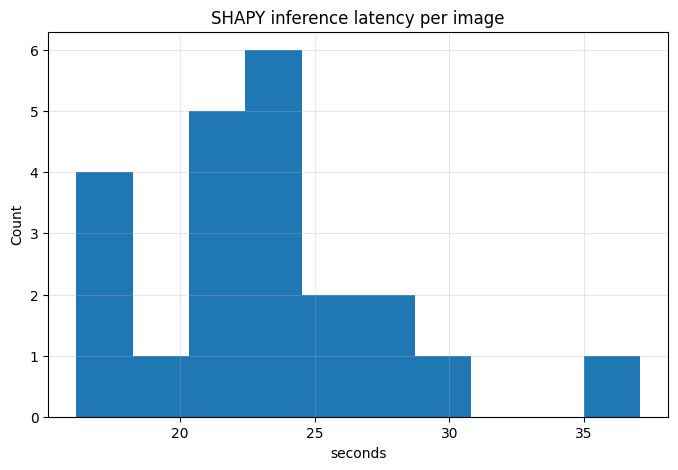

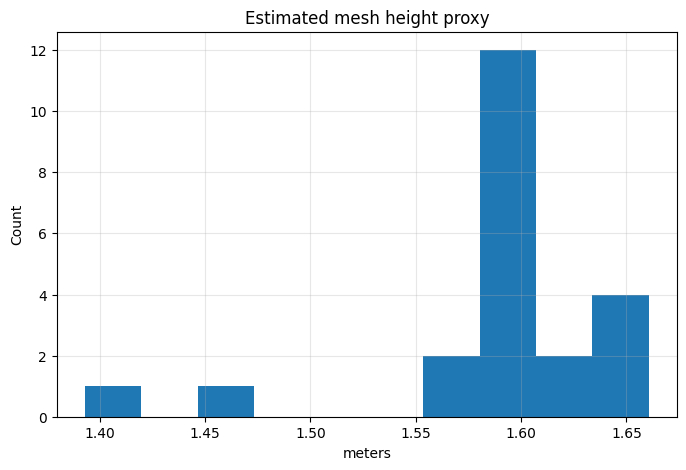

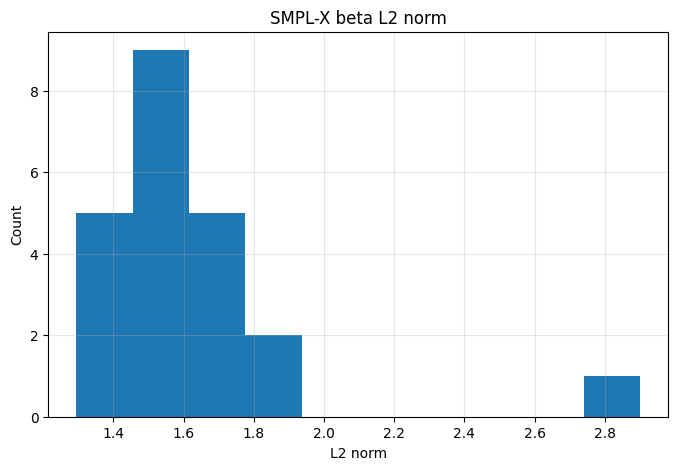

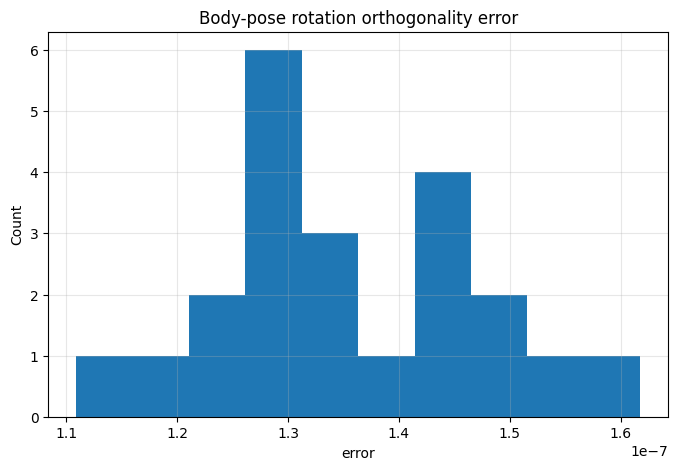

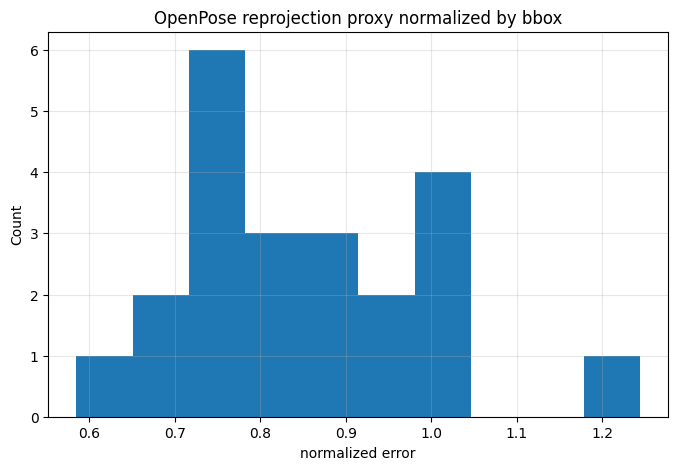

In [50]:
# CELL 28: Optional visual summaries for GT-free SHAPY metrics.

import matplotlib.pyplot as plt

gt_free_df = pd.read_csv(GT_FREE_PER_SAMPLE_PATH)

plot_specs = [
    ("elapsed_sec", "SHAPY inference latency per image", "seconds"),
    ("estimated_height_m", "Estimated mesh height proxy", "meters"),
    ("betas_l2_norm", "SMPL-X beta L2 norm", "L2 norm"),
    ("body_pose_rot_orth_error_mean", "Body-pose rotation orthogonality error", "error"),
    ("openpose_reprojection_proxy_norm_by_bbox_mean", "OpenPose reprojection proxy normalized by bbox", "normalized error"),
]

for col, title, xlabel in plot_specs:
    if col not in gt_free_df.columns:
        print(f"Skipping missing column: {col}")
        continue

    values = pd.to_numeric(gt_free_df[col], errors="coerce").dropna()

    if len(values) == 0:
        print(f"Skipping empty column: {col}")
        continue

    plt.figure(figsize=(8, 5))
    plt.hist(values, bins=min(10, max(3, len(values))))
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()